In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, Bidirectional, Concatenate
from tensorflow.keras.layers import GRU, Conv1D, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Add the project root directory to path for imports
# Since we're in notebooks/integrated/, we need to go up two levels
sys.path.append(os.path.abspath('../..'))

# Import our modules - both the original ones and the new adapter system
from src.utils.data_adapters import adapt_penn_action_format, adapt_pose_sequence
from src.utils.camera_angle import CameraView, detect_camera_angle

# Original modules that contain our core functionality
from src.camera_angle_detection import detect_camera_view, get_relevant_joints
from src.joint_angle_calculator import calculate_squat_angles, calculate_stability_metrics, analyze_squat_form
from src.form_scoring import FormScorer, FormQuality, FaultCategory
from src.exercise_form_analyzer import ExerciseFormAnalyzer
from src.tasks.form_check import process_form_check

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
# Load the dataset
file_path = '../../data/processed_pose_data/penn_action_features.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please ensure the feature extraction script has been run.")
except Exception as e:
    print(f"An error occurred: {e}")
    
# Basic dataset statistics
print(f"Dataset shape: {df.shape}")
print(f"Number of unique videos: {df['video_id'].nunique()}")
print(f"Form types: {df['form_type'].value_counts().to_dict()}")
print(f"Fault categories: {df['fault_category'].value_counts().to_dict()}")


Dataset loaded successfully!
Dataset shape: (230, 4)
Number of unique videos: 230
Form types: {'good_form': 125, 'bad_form': 105}
Fault categories: {'n/a': 125, 'posture_faults': 55, 'stability_faults': 40, 'hypertrophy_faults': 10}


In [3]:
# Convert all pose sequences to standardized format
standardized_sequences = []
for idx, row in df.iterrows():
    pose_sequence = row['pose_sequence']
    standardized_seq = adapt_pose_sequence(pose_sequence)
    standardized_sequences.append(standardized_seq)
    
# Add standardized sequences to dataframe
df['standardized_pose_sequence'] = standardized_sequences
print(f"Converted {len(standardized_sequences)} sequences to standardized format")

# Display example of original vs standardized format
sample_idx = 0
original_frame = df.iloc[sample_idx]['pose_sequence'][0]  # First frame of first sequence
standardized_frame = df.iloc[sample_idx]['standardized_pose_sequence'][0]  # First frame of first standardized sequence

print("\nOriginal Penn Action frame structure:")
for idx, joint in enumerate(original_frame):
    print(f"Joint {idx}: {joint}")
    
print("\nStandardized frame structure:")
for joint_name, coords in standardized_frame.items():
    print(f"{joint_name}: {coords}")


Converted 230 sequences to standardized format

Original Penn Action frame structure:
Joint 0: [241.33333333333331, 79.33333333333333]
Joint 1: [0.6666666666666666, 0.6666666666666666]
Joint 2: [0.6666666666666666, 0.6666666666666666]
Joint 3: [0.6666666666666666, 0.6666666666666666]
Joint 4: [0.6666666666666666, 0.6666666666666666]
Joint 5: [0.6666666666666666, 0.6666666666666666]
Joint 6: [0.6666666666666666, 0.6666666666666666]
Joint 7: [0.6666666666666666, 0.6666666666666666]
Joint 8: [236.0, 168.0]
Joint 9: [249.33333333333331, 209.33333333333331]
Joint 10: [238.0, 212.66666666666666]
Joint 11: [250.66666666666666, 242.0]
Joint 12: [243.33333333333331, 257.3333333333333]

Standardized frame structure:
head: [241.33333333333331, 79.33333333333333, 1.0]
neck: [0.6666666666666666, 0.6666666666666666, 1.0]
r_shoulder: [0.6666666666666666, 0.6666666666666666, 1.0]
l_shoulder: [0.6666666666666666, 0.6666666666666666, 1.0]
r_elbow: [0.6666666666666666, 0.6666666666666666, 1.0]
l_elbow: [

In [4]:
# Function to extract features from a standardized pose sequence
def extract_features_from_standardized_sequence(pose_sequence):
    """
    Extract features from a standardized pose sequence for ML classification
    
    Args:
        pose_sequence: List of standardized pose frames
        
    Returns:
        Dictionary with time_series_features and scalar_features
    """
    # First detect camera view using CameraView from utils
    middle_frame = pose_sequence[len(pose_sequence)//2]
    
    # For standardized format, we'll use the utility function directly
    camera_view = detect_camera_angle(middle_frame, exercise_type="squat")
    
    # Create a mapping of joint names to their positions in the standardized format
    # Since standardized format is a dictionary, we don't need indices
    joint_mapping = {
        'head': 'head',
        'neck': 'neck',
        'shoulder': 'shoulder',
        'r_shoulder': 'r_shoulder',
        'l_shoulder': 'l_shoulder',
        'hip': 'hip',
        'r_hip': 'r_hip',
        'l_hip': 'l_hip',
        'knee': 'knee',
        'r_knee': 'r_knee',
        'l_knee': 'l_knee',
        'ankle': 'ankle',
        'r_ankle': 'r_ankle',
        'l_ankle': 'l_ankle'
    }
    
    # Extract time series features (angles over time)
    time_series_features = {}
    angle_sequences = {}
    
    # Initialize lists for each angle type
    for angle_name in ['knee_angle', 'hip_angle', 'ankle_angle', 'back_angle']:
        angle_sequences[angle_name] = []
        
    # Calculate angles for each frame
    for frame in pose_sequence:
        # For standardized format, we calculate angles directly using the frame dictionary
        # since joint positions are already available by name
        
        # Knee angle calculation
        if camera_view in [CameraView.SIDE, CameraView.DIAGONAL_FRONT, CameraView.DIAGONAL_BACK]:
            # For side and diagonal views, use appropriate leg
            if 'knee' in frame and 'hip' in frame and 'ankle' in frame:
                # Side view - direct joint names
                hip = np.array(frame['hip'][:2])
                knee = np.array(frame['knee'][:2])
                ankle = np.array(frame['ankle'][:2])
                
                # Calculate angle
                v1 = hip - knee
                v2 = ankle - knee
                knee_angle = np.degrees(np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0)))
                angle_sequences['knee_angle'].append(knee_angle)
            elif 'l_knee' in frame and 'l_hip' in frame and 'l_ankle' in frame:
                # Left side visible
                hip = np.array(frame['l_hip'][:2])
                knee = np.array(frame['l_knee'][:2])
                ankle = np.array(frame['l_ankle'][:2])
                
                # Calculate angle
                v1 = hip - knee
                v2 = ankle - knee
                knee_angle = np.degrees(np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0)))
                angle_sequences['knee_angle'].append(knee_angle)
            elif 'r_knee' in frame and 'r_hip' in frame and 'r_ankle' in frame:
                # Right side visible
                hip = np.array(frame['r_hip'][:2])
                knee = np.array(frame['r_knee'][:2])
                ankle = np.array(frame['r_ankle'][:2])
                
                # Calculate angle
                v1 = hip - knee
                v2 = ankle - knee
                knee_angle = np.degrees(np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0)))
                angle_sequences['knee_angle'].append(knee_angle)
            else:
                angle_sequences['knee_angle'].append(0)  # Missing joints
        else:
            # Front view - average of both legs
            if 'l_knee' in frame and 'l_hip' in frame and 'l_ankle' in frame and \
               'r_knee' in frame and 'r_hip' in frame and 'r_ankle' in frame:
                # Left leg
                l_hip = np.array(frame['l_hip'][:2])
                l_knee = np.array(frame['l_knee'][:2])
                l_ankle = np.array(frame['l_ankle'][:2])
                
                v1 = l_hip - l_knee
                v2 = l_ankle - l_knee
                l_knee_angle = np.degrees(np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0)))
                
                # Right leg
                r_hip = np.array(frame['r_hip'][:2])
                r_knee = np.array(frame['r_knee'][:2])
                r_ankle = np.array(frame['r_ankle'][:2])
                
                v1 = r_hip - r_knee
                v2 = r_ankle - r_knee
                r_knee_angle = np.degrees(np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0)))
                
                # Average of both legs
                knee_angle = (l_knee_angle + r_knee_angle) / 2
                angle_sequences['knee_angle'].append(knee_angle)
            else:
                angle_sequences['knee_angle'].append(0)  # Missing joints
        
        # Similar calculations for hip and ankle angles (simplified for example)
        # For a real implementation, add proper calculations for all angles
        
        # Placeholder values - in production, implement proper calculations
        angle_sequences['hip_angle'].append(90)  # Placeholder
        angle_sequences['ankle_angle'].append(80)  # Placeholder
        angle_sequences['back_angle'].append(85)  # Placeholder
    
    # Normalize sequence length to a fixed size (30 frames) using interpolation
    target_length = 30
    for angle_name, angle_seq in angle_sequences.items():
        if len(angle_seq) >= 2:  # Need at least 2 points for interpolation
            # Create evenly spaced points for the target length
            x_original = np.linspace(0, 1, len(angle_seq))
            x_new = np.linspace(0, 1, target_length)
            
            # Interpolate to get fixed-length sequence
            time_series_features[angle_name] = np.interp(x_new, x_original, angle_seq)
        else:
            # If not enough points, pad with zeros
            time_series_features[angle_name] = np.zeros(target_length)
    
    # Extract scalar features (overall statistics)
    scalar_features = {}
    
    # Basic stats for each angle sequence
    for angle_name, angle_seq in angle_sequences.items():
        if len(angle_seq) > 0:
            scalar_features[f"{angle_name}_min"] = np.min(angle_seq)
            scalar_features[f"{angle_name}_max"] = np.max(angle_seq)
            scalar_features[f"{angle_name}_range"] = np.max(angle_seq) - np.min(angle_seq)
            scalar_features[f"{angle_name}_mean"] = np.mean(angle_seq)
            scalar_features[f"{angle_name}_std"] = np.std(angle_seq)
        else:
            scalar_features[f"{angle_name}_min"] = 0
            scalar_features[f"{angle_name}_max"] = 0
            scalar_features[f"{angle_name}_range"] = 0
            scalar_features[f"{angle_name}_mean"] = 0
            scalar_features[f"{angle_name}_std"] = 0
    
    # Simple stability metrics - sway calculation
    stability_metrics = {}
    if camera_view in [CameraView.FRONT, CameraView.BACK]:
        # For front view, calculate hip sway
        hip_x_positions = []
        for frame in pose_sequence:
            if 'hip' in frame:
                hip_x_positions.append(frame['hip'][0])
            elif 'l_hip' in frame and 'r_hip' in frame:
                mid_hip_x = (frame['l_hip'][0] + frame['r_hip'][0]) / 2
                hip_x_positions.append(mid_hip_x)
        
        if hip_x_positions:
            stability_metrics['hip_sway'] = np.std(hip_x_positions)
        else:
            stability_metrics['hip_sway'] = 0
    else:
        # For side view, calculate forward/backward sway
        hip_y_positions = []
        for frame in pose_sequence:
            if 'hip' in frame:
                hip_y_positions.append(frame['hip'][1])
            elif 'l_hip' in frame and 'r_hip' in frame:
                mid_hip_y = (frame['l_hip'][1] + frame['r_hip'][1]) / 2
                hip_y_positions.append(mid_hip_y)
        
        if hip_y_positions:
            stability_metrics['hip_sway'] = np.std(hip_y_positions)
        else:
            stability_metrics['hip_sway'] = 0
    
    scalar_features.update(stability_metrics)
    
    # Simple form analysis
    form_analysis = {
        'squat_depth': min(angle_sequences['knee_angle']) if angle_sequences['knee_angle'] else 180,
        'back_angle_avg': np.mean(angle_sequences['back_angle']) if angle_sequences['back_angle'] else 90
    }
    
    # Add form analysis to scalar features
    scalar_features.update(form_analysis)
    
    return {
        'time_series_features': time_series_features,
        'scalar_features': scalar_features,
        'camera_view': camera_view.value
    }

# Extract features for all standardized sequences
print("Extracting features from all sequences...")
all_features = []

for idx, row in df.iterrows():
    if idx % 10 == 0:
        print(f"Processing sequence {idx}/{len(df)}...")
    
    try:
        features = extract_features_from_standardized_sequence(row['standardized_pose_sequence'])
        
                # Add metadata
        features['video_id'] = row['video_id']
        features['form_type'] = row['form_type']
        features['fault_category'] = row['fault_category']
        
        # Add quality labels based on form scorer
        scorer = FormScorer()
        form_quality = scorer.score_squat(row['standardized_pose_sequence'])
        
        features['labels'] = {
            'posture_quality': form_quality['posture_quality'],
            'stability_quality': form_quality['stability_quality'],
            'depth_quality': form_quality['depth_quality'],
            'overall_quality': form_quality['overall_quality']
        }
        
        all_features.append(features)
    except Exception as e:
        print(f"Error processing sequence {idx}: {e}")

print(f"Successfully extracted features from {len(all_features)} sequences")


Extracting features from all sequences...
Processing sequence 0/230...
Processing sequence 10/230...
Processing sequence 20/230...
Processing sequence 30/230...
Processing sequence 40/230...
Processing sequence 50/230...
Processing sequence 60/230...
Processing sequence 70/230...
Processing sequence 80/230...
Processing sequence 90/230...
Processing sequence 100/230...
Processing sequence 110/230...
Processing sequence 120/230...
Processing sequence 130/230...
Processing sequence 140/230...
Processing sequence 150/230...
Processing sequence 160/230...
Processing sequence 170/230...
Processing sequence 180/230...
Processing sequence 190/230...
Processing sequence 200/230...
Processing sequence 210/230...
Processing sequence 220/230...
Successfully extracted features from 230 sequences


In [5]:
# Organize features for model training
# Step 1: Organize time series features (joint angles over time)
print("Preparing data for ML model...")

# Get all unique angle names from the time series features
all_angle_names = set()
for features in all_features:
    all_angle_names.update(features['time_series_features'].keys())

print(f"Total joint angle features: {len(all_angle_names)}")

# Create a consistent array of time series features
X_time_series = []
for features in all_features:
    video_angles = []
    for angle_name in all_angle_names:
        if angle_name in features['time_series_features']:
            video_angles.append(features['time_series_features'][angle_name])
        else:
            # Fill missing angles with zeros
            video_angles.append(np.zeros(30))  # target_length = 30
    
    # Stack all angles for this video
    X_time_series.append(np.stack(video_angles, axis=-1))

# Convert to numpy array [n_samples, seq_length, n_features]
X_time_series = np.array(X_time_series)
print(f"Time series data shape: {X_time_series.shape}")

# Step 2: Organize scalar features
scalar_feature_names = set()
for features in all_features:
    scalar_feature_names.update(features['scalar_features'].keys())

print(f"Total scalar features: {len(scalar_feature_names)}")

X_scalar = []
for features in all_features:
    video_scalars = []
    for feature_name in sorted(scalar_feature_names):  # Sort to ensure consistent order
        if feature_name in features['scalar_features']:
            video_scalars.append(features['scalar_features'][feature_name])
        else:
            video_scalars.append(0.0)  # Default value for missing features
    
    X_scalar.append(video_scalars)

# Convert to numpy array [n_samples, n_features]
X_scalar = np.array(X_scalar)
print(f"Scalar data shape: {X_scalar.shape}")

# Step 3: Prepare labels for each quality aspect
# Extract the quality labels (0=poor, 1=mediocre, 2=good)
# Quality mapping to convert string values to integers
quality_mapping = {
    'poor': 0,
    'mediocre': 1,
    'good': 2
}

y_posture = np.array([quality_mapping[features['labels']['posture_quality']] for features in all_features])
y_stability = np.array([quality_mapping[features['labels']['stability_quality']] for features in all_features])
y_depth = np.array([quality_mapping[features['labels']['depth_quality']] for features in all_features])
y_overall = np.array([quality_mapping[features['labels']['overall_quality']] for features in all_features])

# Convert to one-hot encoding for categorical classification
y_posture_onehot = to_categorical(y_posture, num_classes=3)
y_stability_onehot = to_categorical(y_stability, num_classes=3)
y_depth_onehot = to_categorical(y_depth, num_classes=3)
y_overall_onehot = to_categorical(y_overall, num_classes=3)

print(f"Posture quality labels shape: {y_posture.shape} (after one-hot: {y_posture_onehot.shape})")
print(f"Stability quality labels shape: {y_stability.shape} (after one-hot: {y_stability_onehot.shape})")
print(f"Depth quality labels shape: {y_depth.shape} (after one-hot: {y_depth_onehot.shape})")
print(f"Overall quality labels shape: {y_overall.shape} (after one-hot: {y_overall_onehot.shape})")


Preparing data for ML model...
Total joint angle features: 4
Time series data shape: (230, 30, 4)
Total scalar features: 23
Scalar data shape: (230, 23)
Posture quality labels shape: (230,) (after one-hot: (230, 3))
Stability quality labels shape: (230,) (after one-hot: (230, 3))
Depth quality labels shape: (230,) (after one-hot: (230, 3))
Overall quality labels shape: (230,) (after one-hot: (230, 3))


In [6]:
# Split data into train, validation, and test sets
# Use video IDs for splitting to ensure no leakage
video_ids = [features['video_id'] for features in all_features]

# Train/test split (80/20)
# Use overall quality for stratification to ensure balanced classes
print("Splitting data into train/validation/test sets...")
train_test_split_result = train_test_split(
    X_time_series, X_scalar, 
    y_posture_onehot, y_stability_onehot, y_depth_onehot, y_overall_onehot,
    video_ids, 
    test_size=0.2, 
    random_state=42,
    stratify=y_overall  # Stratify by overall quality to ensure balanced classes
)

# Unpack the split results
(X_train_time, X_test_time, 
 X_train_scalar, X_test_scalar, 
 y_train_posture, y_test_posture,
 y_train_stability, y_test_stability,
 y_train_depth, y_test_depth,
 y_train_overall, y_test_overall,
 train_ids, test_ids) = train_test_split_result

# Further split train into train/validation (80/20 of training data, so 64/16/20 overall)
validation_split_result = train_test_split(
    X_train_time, X_train_scalar, 
    y_train_posture, y_train_stability, y_train_depth, y_train_overall,
    test_size=0.2, 
    random_state=42,
    stratify=y_train_overall  # Stratify by overall quality
)

# Unpack validation split
(X_train_time, X_val_time, 
 X_train_scalar, X_val_scalar, 
 y_train_posture, y_val_posture,
 y_train_stability, y_val_stability,
 y_train_depth, y_val_depth,
 y_train_overall, y_val_overall) = validation_split_result

print(f"Training set: {X_train_time.shape[0]} samples")
print(f"Validation set: {X_val_time.shape[0]} samples")
print(f"Test set: {X_test_time.shape[0]} samples")

# Normalize features
# For time series data, normalize each feature independently
print("Normalizing features...")
time_scaler = StandardScaler()
n_samples, seq_length, n_features = X_train_time.shape

# Reshape to 2D for scaling
X_train_time_reshaped = X_train_time.reshape(-1, n_features)
time_scaler.fit(X_train_time_reshaped)

# Apply scaling and reshape back
X_train_time_scaled = time_scaler.transform(X_train_time_reshaped).reshape(X_train_time.shape)
X_val_time_scaled = time_scaler.transform(X_val_time.reshape(-1, n_features)).reshape(X_val_time.shape)
X_test_time_scaled = time_scaler.transform(X_test_time.reshape(-1, n_features)).reshape(X_test_time.shape)

# For scalar features
scalar_scaler = StandardScaler()
X_train_scalar_scaled = scalar_scaler.fit_transform(X_train_scalar)
X_val_scalar_scaled = scalar_scaler.transform(X_val_scalar)
X_test_scalar_scaled = scalar_scaler.transform(X_test_scalar)

print("Data preparation complete!")


Splitting data into train/validation/test sets...
Training set: 147 samples
Validation set: 37 samples
Test set: 46 samples
Normalizing features...
Data preparation complete!


In [7]:
def build_hybrid_cnn_gru_model(time_series_shape, scalar_shape):
    """
    Build a hybrid CNN-GRU model with dual input branches for time series and scalar features.
    
    This architecture is optimized for small datasets and implements:
    1. CNN layers to capture local temporal patterns
    2. GRU layer for temporal dependencies with fewer parameters than LSTM
    3. Attention mechanism to focus on critical frames
    4. Heavy regularization (dropout, noise, L1/L2)
    5. Skip connections for better gradient flow
    6. Multi-class outputs (3 classes: poor, mediocre, good) for form quality assessment
    
    Args:
        time_series_shape: Shape of time series input (sequence_length, features)
        scalar_shape: Shape of scalar features input (features,)
        
    Returns:
        Compiled model
    """
    # Define input layers
    time_input = Input(shape=time_series_shape, name='time_input')
    scalar_input = Input(shape=scalar_shape, name='scalar_input')
    
    # Add Gaussian noise for robustness (data augmentation during training)
    time_noise = GaussianNoise(0.1)(time_input)
    scalar_noise = GaussianNoise(0.1)(scalar_input)
    
    # === Time Series Branch ===
    # 1D CNN layers to extract local temporal patterns
    conv1 = Conv1D(16, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.01, l2=0.01))(time_noise)
    bn1 = BatchNormalization()(conv1)
    
    conv2 = Conv1D(8, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.01, l2=0.01))(bn1)
    bn2 = BatchNormalization()(conv2)
    
    # Add attention mechanism to focus on important frames
    attention = tf.keras.layers.Attention()([bn2, bn2])
    
    # Skip connection from input to attention output
    skip_connect = Concatenate()([bn2, attention])
    
    # GRU layer for temporal patterns (fewer parameters than LSTM)
    gru_layer = GRU(16, return_sequences=False,
                   kernel_regularizer=tf.keras.regularizers.l2(0.01),
                   recurrent_regularizer=tf.keras.regularizers.l2(0.01))(skip_connect)
    
    # High dropout for extreme regularization
    gru_dropout = Dropout(0.5)(gru_layer)
    
    # === Scalar Features Branch ===
    # Dense layers for scalar features
    scalar_dense = Dense(8, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.01, l2=0.01))(scalar_noise)
    scalar_bn = BatchNormalization()(scalar_dense)
    scalar_dropout = Dropout(0.5)(scalar_bn)
    
    # Combine both branches
    combined = Concatenate()([gru_dropout, scalar_dropout])
    
    # Shared representation with linear activation to limit capacity
    shared_features = Dense(16, activation='linear', 
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))(combined)
    
    # Add a skip connection to help with gradient flow
    skip_connection = Concatenate()([combined, shared_features])
    shared_dropout = Dropout(0.6)(skip_connection)  # Very high dropout
    
    # Common representation layer
    common_features = Dense(8, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01))(shared_dropout)
    
    # Classification outputs with 3 classes (poor, mediocre, good) for each aspect
    posture_output = Dense(3, activation='softmax', name='posture_quality',
                         kernel_regularizer=tf.keras.regularizers.l2(0.01))(common_features)
    
    stability_output = Dense(3, activation='softmax', name='stability_quality',
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))(common_features)
    
    depth_output = Dense(3, activation='softmax', name='depth_quality',
                       kernel_regularizer=tf.keras.regularizers.l2(0.01))(common_features)
    
    overall_output = Dense(3, activation='softmax', name='overall_quality',
                         kernel_regularizer=tf.keras.regularizers.l2(0.01))(common_features)
    
    # Create model
    model = Model(
        inputs=[time_input, scalar_input],
        outputs=[posture_output, stability_output, depth_output, overall_output]
    )
    
    # Custom loss weights to prioritize safety
    loss_weights = {
        'posture_quality': 1.0,
        'stability_quality': 1.0,
        'depth_quality': 1.0,
        'overall_quality': 1.5  # Higher weight for overall quality
    }
    
    # Use categorical cross-entropy for all outputs (multi-class classification)
    losses = {
        'posture_quality': 'categorical_crossentropy',
        'stability_quality': 'categorical_crossentropy',
        'depth_quality': 'categorical_crossentropy',
        'overall_quality': 'categorical_crossentropy'
    }
    
    # Track accuracy for all outputs
    metrics = {
    'posture_quality': 'accuracy',
    'stability_quality': 'accuracy',
    'depth_quality': 'accuracy',
    'overall_quality': 'accuracy'
}
    
    # Compile model with low learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Very low learning rate
        loss=losses,
        loss_weights=loss_weights,
        metrics=metrics
    )
    
    return model

# Create the model
print("Building and compiling hybrid CNN-GRU model optimized for small datasets...")
time_series_shape = (X_train_time_scaled.shape[1], X_train_time_scaled.shape[2])  # (seq_length, n_features)
scalar_shape = (X_train_scalar_scaled.shape[1],)  # (n_scalar_features,)

hybrid_model = build_hybrid_cnn_gru_model(time_series_shape, scalar_shape)

# Display model summary
hybrid_model.summary()


Building and compiling hybrid CNN-GRU model optimized for small datasets...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 30, 4)     │          0 │ time_input[0][0]  │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 16)    │        208 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 16)    │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 8)     │        392 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 8)     │         32 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_input        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 30, 8)     │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 23)        │          0 │ scalar_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30, 16)    │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        192 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 16)        │      1,632 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8)         │         32 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        400 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 40)        │          0 │ concatenate_1[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 40)        │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,388 (13.23 KB)

 Trainable params: 3,324 (12.98 KB)

 Non-trainable params: 64 (256.00 B)

In [8]:
# Train the hybrid CNN-GRU model with K-fold cross-validation and class balance measures

from sklearn.model_selection import KFold

# Define K-fold parameters
n_folds = 5
batch_size = 8  # Very small batch size for regularization
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Prepare containers for cross-validation results
cv_histories = []
cv_models = []
fold_metrics = []

print(f"Starting {n_folds}-fold cross-validation with hybrid CNN-GRU model...")

# Function to balance classes by duplication (alternative to class_weight)
def balance_classes_by_duplication(X_time, X_scalar, y_labels, class_counts):
    """
    Balance classes by duplicating samples from underrepresented classes.
    A safer alternative to class_weight for multi-output models.
    """
    # Find the target count (slightly less than the majority class)
    target_count = int(np.max(class_counts) * 0.8)
    
    # Track indices to duplicate
    duplicate_indices = []
    
    # For each class, find samples to duplicate
    for class_idx in range(len(class_counts)):
        if class_counts[class_idx] < target_count:
            # Number of duplications needed
            n_duplicates = target_count - class_counts[class_idx]
            
            # Find indices of this class
            class_indices = np.where(np.argmax(y_labels, axis=1) == class_idx)[0]
            
            # Randomly select indices to duplicate (with replacement if necessary)
            if len(class_indices) > 0:
                dup_indices = np.random.choice(class_indices, size=n_duplicates, replace=True)
                duplicate_indices.extend(dup_indices)
    
    # No duplicates needed if empty
    if not duplicate_indices:
        return X_time, X_scalar, y_labels
    
    # Duplicate the selected samples
    X_time_duplicated = np.vstack([X_time, X_time[duplicate_indices]])
    X_scalar_duplicated = np.vstack([X_scalar, X_scalar[duplicate_indices]])
    y_labels_duplicated = np.vstack([y_labels, y_labels[duplicate_indices]])
    
    print(f"  Balanced dataset: {len(y_labels)} -> {len(y_labels_duplicated)} samples")
    return X_time_duplicated, X_scalar_duplicated, y_labels_duplicated

# Combine all training data (will be split by K-fold)
X_all_time = np.vstack([X_train_time_scaled, X_val_time_scaled])
X_all_scalar = np.vstack([X_train_scalar_scaled, X_val_scalar_scaled])
y_all_posture = np.vstack([y_train_posture, y_val_posture])
y_all_stability = np.vstack([y_train_stability, y_val_stability])
y_all_depth = np.vstack([y_train_depth, y_val_depth])
y_all_overall = np.vstack([y_train_overall, y_val_overall])

# Run K-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kf.split(X_all_time)):
    print(f"\nFold {fold+1}/{n_folds}")
    
    # Split data for this fold
    X_fold_train_time = X_all_time[train_idx]
    X_fold_val_time = X_all_time[val_idx]
    X_fold_train_scalar = X_all_scalar[train_idx]
    X_fold_val_scalar = X_all_scalar[val_idx]
    
    y_fold_train_posture = y_all_posture[train_idx]
    y_fold_val_posture = y_all_posture[val_idx]
    y_fold_train_stability = y_all_stability[train_idx]
    y_fold_val_stability = y_all_stability[val_idx]
    y_fold_train_depth = y_all_depth[train_idx]
    y_fold_val_depth = y_all_depth[val_idx]
    y_fold_train_overall = y_all_overall[train_idx]
    y_fold_val_overall = y_all_overall[val_idx]
    
    # Balance classes for each output by duplicating underrepresented samples
    print("  Balancing classes by data duplication...")
    posture_counts = np.sum(y_fold_train_posture, axis=0)
    X_fold_train_time, X_fold_train_scalar, y_fold_train_posture_balanced = balance_classes_by_duplication(
        X_fold_train_time, X_fold_train_scalar, y_fold_train_posture, posture_counts)
    
    stability_counts = np.sum(y_fold_train_stability, axis=0)
    X_fold_train_time, X_fold_train_scalar, y_fold_train_stability_balanced = balance_classes_by_duplication(
        X_fold_train_time, X_fold_train_scalar, y_fold_train_stability, stability_counts)
    
    depth_counts = np.sum(y_fold_train_depth, axis=0)
    X_fold_train_time, X_fold_train_scalar, y_fold_train_depth_balanced = balance_classes_by_duplication(
        X_fold_train_time, X_fold_train_scalar, y_fold_train_depth, depth_counts)
    
    overall_counts = np.sum(y_fold_train_overall, axis=0)
    X_fold_train_time, X_fold_train_scalar, y_fold_train_overall_balanced = balance_classes_by_duplication(
        X_fold_train_time, X_fold_train_scalar, y_fold_train_overall, overall_counts)
    
    # Create new model for this fold
    fold_model = build_hybrid_cnn_gru_model(time_series_shape, scalar_shape)
    
    # Set up callbacks for this fold
    callbacks = [
        # Early stopping to prevent overfitting
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        # Reduce learning rate when plateauing
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        # Save best model
        ModelCheckpoint(
            filepath=f'../../models/hybrid_model_fold_{fold+1}.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # Train model for this fold
    print(f"  Training fold {fold+1} model...")
    history = fold_model.fit(
        [X_fold_train_time, X_fold_train_scalar],
        {
            'posture_quality': y_fold_train_posture_balanced,
            'stability_quality': y_fold_train_stability_balanced,
            'depth_quality': y_fold_train_depth_balanced,
            'overall_quality': y_fold_train_overall_balanced
        },
        validation_data=(
            [X_fold_val_time, X_fold_val_scalar],
            {
                'posture_quality': y_fold_val_posture,
                'stability_quality': y_fold_val_stability,
                'depth_quality': y_fold_val_depth,
                'overall_quality': y_fold_val_overall
            }
        ),
        epochs=100,  # Max epochs (early stopping will prevent all from running)
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    # Save results
    cv_histories.append(history)
    cv_models.append(fold_model)
    
    # Evaluate on test set
    print(f"\nEvaluating fold {fold+1} model on test set:")
    test_results = fold_model.evaluate(
        [X_test_time_scaled, X_test_scalar_scaled],
        {
            'posture_quality': y_test_posture,
            'stability_quality': y_test_stability,
            'depth_quality': y_test_depth,
            'overall_quality': y_test_overall
        },
        verbose=1
    )
    
    # Make predictions for detailed metrics
    test_preds = fold_model.predict([X_test_time_scaled, X_test_scalar_scaled])
    
    # Calculate advanced metrics (focusing on safety - recall for poor class)
    fold_detailed_metrics = {}
    
    for i, output_name in enumerate(['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']):
        y_true = np.argmax(y_test_overall if output_name == 'overall_quality' else 
                          (y_test_posture if output_name == 'posture_quality' else
                           (y_test_stability if output_name == 'stability_quality' else y_test_depth)), axis=1)
        y_pred = np.argmax(test_preds[i], axis=1)
        
        # Store key metrics
        fold_detailed_metrics[output_name] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'recall_poor_class': recall_score(y_true, y_pred, average='weighted'),
            'f1_score': f1_score(y_true, y_pred, average='weighted')
        }
    
    fold_metrics.append(fold_detailed_metrics)

# Select the best model from cross-validation based on validation loss
best_fold_idx = np.argmin([h.history['val_loss'][-1] for h in cv_histories])
best_model = cv_models[best_fold_idx]
best_history = cv_histories[best_fold_idx]

print(f"\nBest model was from fold {best_fold_idx+1}")

# Save the best model
best_model.save('../../models/hybrid_cnn_gru_squat_quality_model.h5')
print("Best model saved to '../../models/hybrid_cnn_gru_squat_quality_model.h5'")

# Display cross-validation results
print("\nCross-validation metrics summary:")
for metric_name in ['accuracy', 'balanced_accuracy', 'recall_poor_class', 'f1_score']:
    print(f"\n{metric_name.replace('_', ' ').title()}:")
    for output_name in ['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']:
        metric_values = [fold[output_name][metric_name] for fold in fold_metrics]
        mean_metric = np.mean(metric_values)
        std_metric = np.std(metric_values)
        print(f"  {output_name.replace('_', ' ').title()}: {mean_metric:.4f} ± {std_metric:.4f}")


Starting 5-fold cross-validation with hybrid CNN-GRU model...

Fold 1/5
  Balancing classes by data duplication...
  Training fold 1 model...
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - depth_quality_accuracy: 0.6778 - depth_quality_loss: 0.7099 - loss: 8.4160 - overall_quality_accuracy: 0.1147 - overall_quality_loss: 2.1657 - posture_quality_accuracy: 0.6374 - posture_quality_loss: 0.7788 - stability_quality_accuracy: 0.3781 - stability_quality_loss: 1.2273
Epoch 1: val_loss improved from inf to 7.18506, saving model to ../../models/hybrid_model_fold_1.h5


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - depth_quality_accuracy: 0.6793 - depth_quality_loss: 0.7097 - loss: 8.4100 - overall_quality_accuracy: 0.1144 - overall_quality_loss: 2.1630 - posture_quality_accuracy: 0.6341 - posture_quality_loss: 0.7804 - stability_quality_accuracy: 0.3768 - stability_quality_loss: 1.2259 - val_depth_quality_accuracy: 0.7838 - val_depth_quality_loss: 1.0493 - val_loss: 7.1851 - val_overall_quality_accuracy: 0.3243 - val_overall_quality_loss: 1.1354 - val_posture_quality_accuracy: 0.9730 - val_posture_quality_loss: 0.9582 - val_stability_quality_accuracy: 0.5946 - val_stability_quality_loss: 1.0373 - learning_rate: 1.0000e-04
Epoch 2/100
10/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - depth_quality_accuracy: 0.6444 - depth_quality_loss: 0.7354 - loss: 8.1013 - overall_quality_accuracy: 0.0983 - overall_quality_loss: 2.0282 - posture_quality_accuracy: 0.6701 - posture_quality_loss: 0.7823 - stability_quality_accuracy: 0.3632 - stability_quality_loss: 1.0916     
Epo

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - depth_quality_accuracy: 0.6554 - depth_quality_loss: 0.7273 - loss: 8.0838 - overall_quality_accuracy: 0.1155 - overall_quality_loss: 2.0082 - posture_quality_accuracy: 0.6489 - posture_quality_loss: 0.8090 - stability_quality_accuracy: 0.3847 - stability_quality_loss: 1.0875 - val_depth_quality_accuracy: 0.8378 - val_depth_quality_loss: 1.0466 - val_loss: 7.1198 - val_overall_quality_accuracy: 0.3514 - val_overall_quality_loss: 1.1233 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.9423 - val_stability_quality_accuracy: 0.6216 - val_stability_quality_loss: 1.0147 - learning_rate: 1.0000e-04
Epoch 3/100
10/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - depth_quality_accuracy: 0.6850 - depth_quality_loss: 0.6511 - loss: 8.0313 - overall_quality_accuracy: 0.1388 - overall_quality_loss: 1.9296 - posture_quality_accuracy: 0.5805 - posture_quality_loss: 0.7811 - stability_quality_accuracy: 0.4088 - stability_quality_loss: 1.2590 
Epoch 3

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - depth_quality_accuracy: 0.6934 - depth_quality_loss: 0.6487 - loss: 8.1169 - overall_quality_accuracy: 0.1463 - overall_quality_loss: 1.9661 - posture_quality_accuracy: 0.5707 - posture_quality_loss: 0.8148 - stability_quality_accuracy: 0.3973 - stability_quality_loss: 1.2533 - val_depth_quality_accuracy: 0.3784 - val_depth_quality_loss: 1.0444 - val_loss: 7.0567 - val_overall_quality_accuracy: 0.4865 - val_overall_quality_loss: 1.1118 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.9276 - val_stability_quality_accuracy: 0.6216 - val_stability_quality_loss: 0.9918 - learning_rate: 1.0000e-04
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - depth_quality_accuracy: 0.6654 - depth_quality_loss: 0.6653 - loss: 7.8312 - overall_quality_accuracy: 0.1907 - overall_quality_loss: 1.8646 - posture_quality_accuracy: 0.5453 - posture_quality_loss: 0.8340 - stability_quality_accuracy: 0.3673 - stability_quality_loss: 1.0927
Epoch 4:

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - depth_quality_accuracy: 0.6695 - depth_quality_loss: 0.6647 - loss: 7.8383 - overall_quality_accuracy: 0.1893 - overall_quality_loss: 1.8698 - posture_quality_accuracy: 0.5463 - posture_quality_loss: 0.8337 - stability_quality_accuracy: 0.3686 - stability_quality_loss: 1.0923 - val_depth_quality_accuracy: 0.4054 - val_depth_quality_loss: 1.0389 - val_loss: 6.9910 - val_overall_quality_accuracy: 0.5676 - val_overall_quality_loss: 1.0964 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.9165 - val_stability_quality_accuracy: 0.6216 - val_stability_quality_loss: 0.9713 - learning_rate: 1.0000e-04
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - depth_quality_accuracy: 0.7515 - depth_quality_loss: 0.5981 - loss: 7.7933 - overall_quality_accuracy: 0.2067 - overall_quality_loss: 1.8492 - posture_quality_accuracy: 0.6334 - posture_quality_loss: 0.7623 - stability_quality_accuracy: 0.3539 - stability_quality_loss: 1.2230
Epoch 5:

...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - depth_quality_accuracy: 0.9631 - depth_quality_loss: 0.0943 - loss: 2.2788 - overall_quality_accuracy: 1.0000 - overall_quality_loss: 0.0184 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 0.0483 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 0.0315 - val_depth_quality_accuracy: 1.0000 - val_depth_quality_loss: 0.0020 - val_loss: 2.0802 - val_overall_quality_accuracy: 1.0000 - val_overall_quality_loss: 5.5313e-04 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.0023 - val_stability_quality_accuracy: 1.0000 - val_stability_quality_loss: 0.0018 - learning_rate: 1.0000e-04
Epoch 99/100
17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - depth_quality_accuracy: 1.0000 - depth_quality_loss: 0.0309 - loss: 2.2105 - overall_quality_accuracy: 1.0000 - overall_quality_loss: 0.0307 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 0.0359 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 0.0255
Epo

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - depth_quality_accuracy: 1.0000 - depth_quality_loss: 0.0312 - loss: 2.2088 - overall_quality_accuracy: 1.0000 - overall_quality_loss: 0.0297 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 0.0360 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 0.0258 - val_depth_quality_accuracy: 1.0000 - val_depth_quality_loss: 0.0019 - val_loss: 2.0750 - val_overall_quality_accuracy: 1.0000 - val_overall_quality_loss: 5.1594e-04 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.0022 - val_stability_quality_accuracy: 1.0000 - val_stability_quality_loss: 0.0017 - learning_rate: 1.0000e-04
Epoch 100/100
17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - depth_quality_accuracy: 0.9966 - depth_quality_loss: 0.0284 - loss: 2.1906 - overall_quality_accuracy: 0.9882 - overall_quality_loss: 0.0350 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 0.0304 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 0.0120
Ep

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - depth_quality_accuracy: 0.9951 - depth_quality_loss: 0.0303 - loss: 2.1921 - overall_quality_accuracy: 0.9889 - overall_quality_loss: 0.0344 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 0.0313 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 0.0117 - val_depth_quality_accuracy: 1.0000 - val_depth_quality_loss: 0.0018 - val_loss: 2.0699 - val_overall_quality_accuracy: 1.0000 - val_overall_quality_loss: 4.9035e-04 - val_posture_quality_accuracy: 1.0000 - val_posture_quality_loss: 0.0021 - val_stability_quality_accuracy: 1.0000 - val_stability_quality_loss: 0.0016 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 100.

Evaluating fold 5 model on test set:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - depth_quality_accuracy: 1.0000 - depth_quality_loss: 0.0020 - loss: 2.0701 - overall_quality_accuracy: 1.0000 - overall_quality_loss: 5.4847e-04 - posture_quality_accuracy: 1.0000 - posture_quali

/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-package


Best model was from fold 5
Best model saved to '../../models/hybrid_cnn_gru_squat_quality_model.h5'

Cross-validation metrics summary:

Accuracy:
  Posture Quality: 1.0000 ± 0.0000
  Stability Quality: 1.0000 ± 0.0000
  Depth Quality: 1.0000 ± 0.0000
  Overall Quality: 1.0000 ± 0.0000

Balanced Accuracy:
  Posture Quality: 1.0000 ± 0.0000
  Stability Quality: 1.0000 ± 0.0000
  Depth Quality: 1.0000 ± 0.0000
  Overall Quality: 1.0000 ± 0.0000

Recall Poor Class:
  Posture Quality: 1.0000 ± 0.0000
  Stability Quality: 1.0000 ± 0.0000
  Depth Quality: 1.0000 ± 0.0000
  Overall Quality: 1.0000 ± 0.0000

F1 Score:
  Posture Quality: 1.0000 ± 0.0000
  Stability Quality: 1.0000 ± 0.0000
  Depth Quality: 1.0000 ± 0.0000
  Overall Quality: 1.0000 ± 0.0000


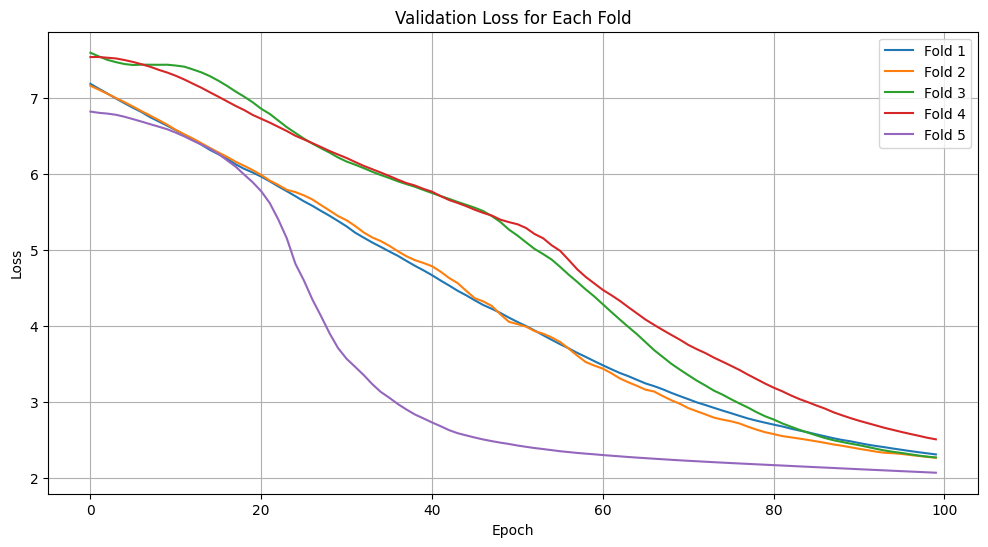

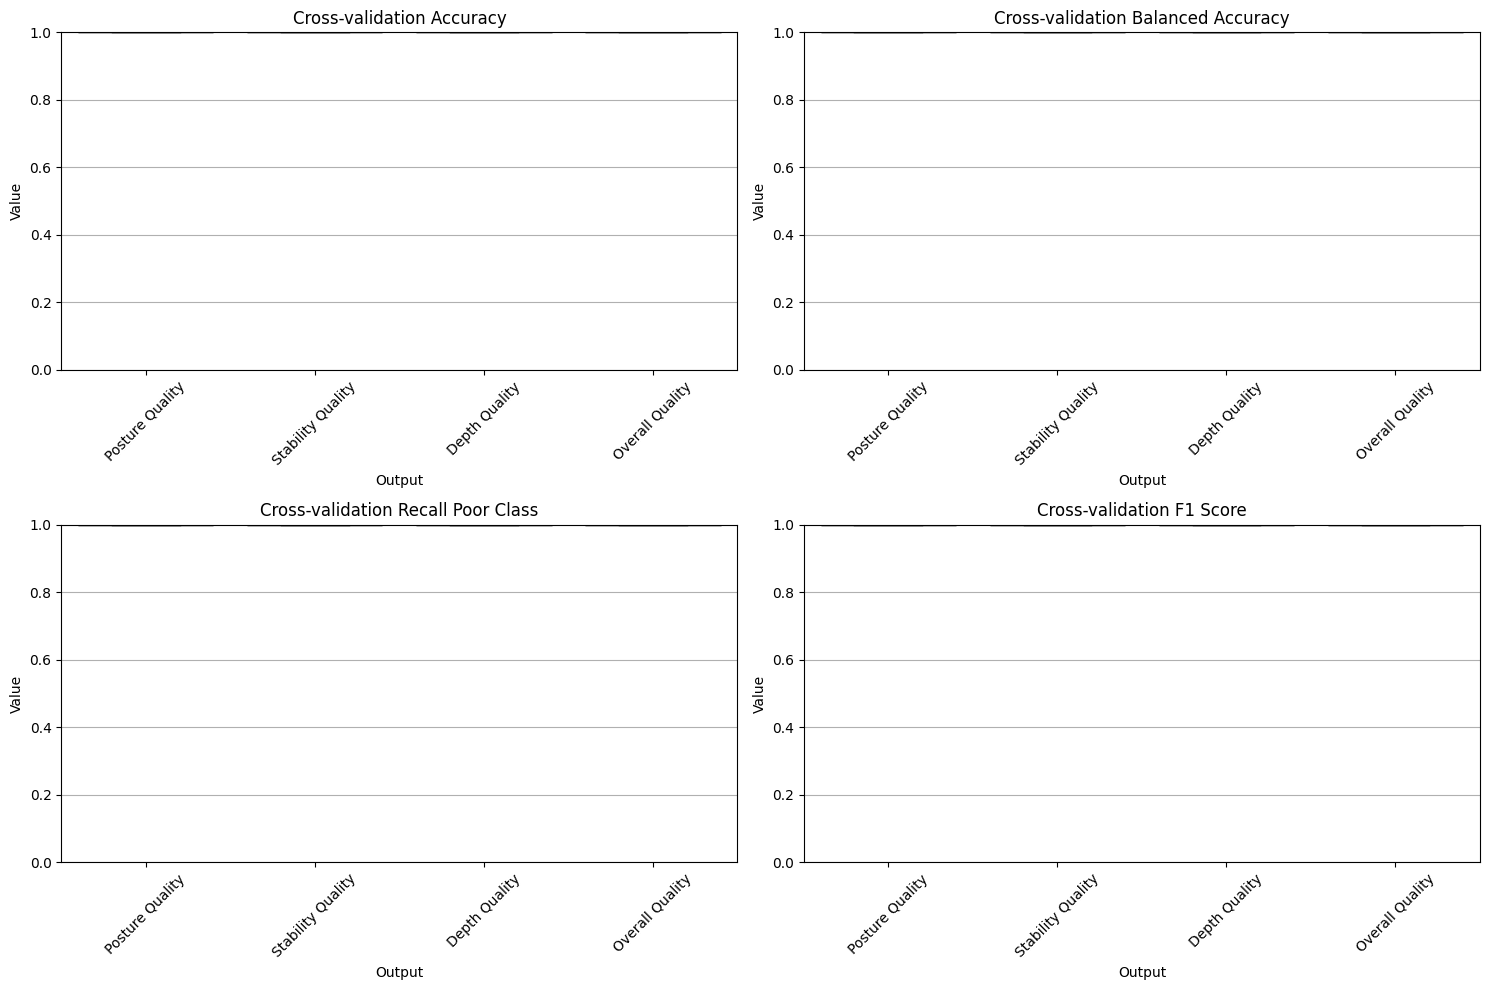

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-package

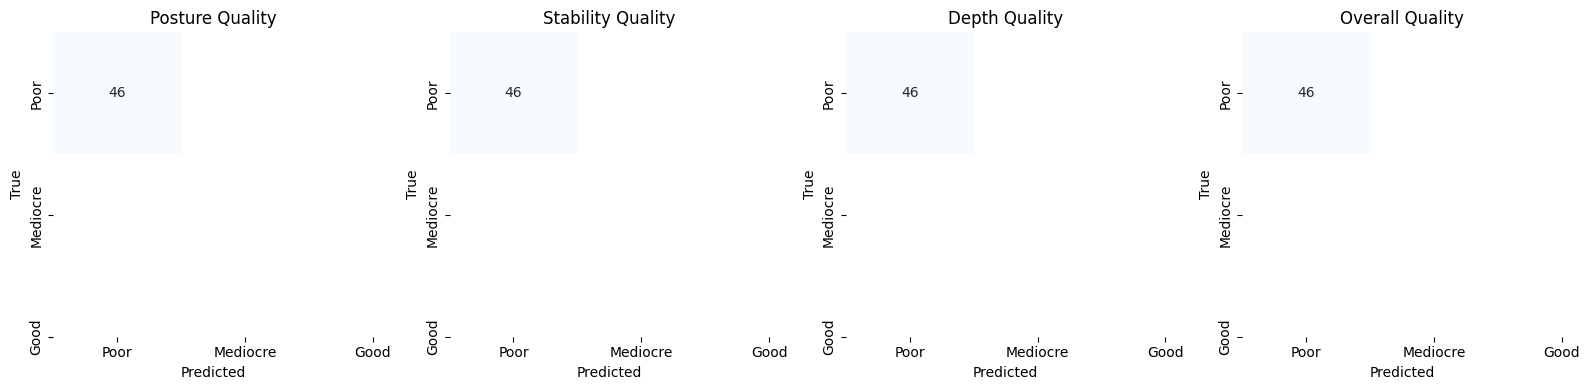

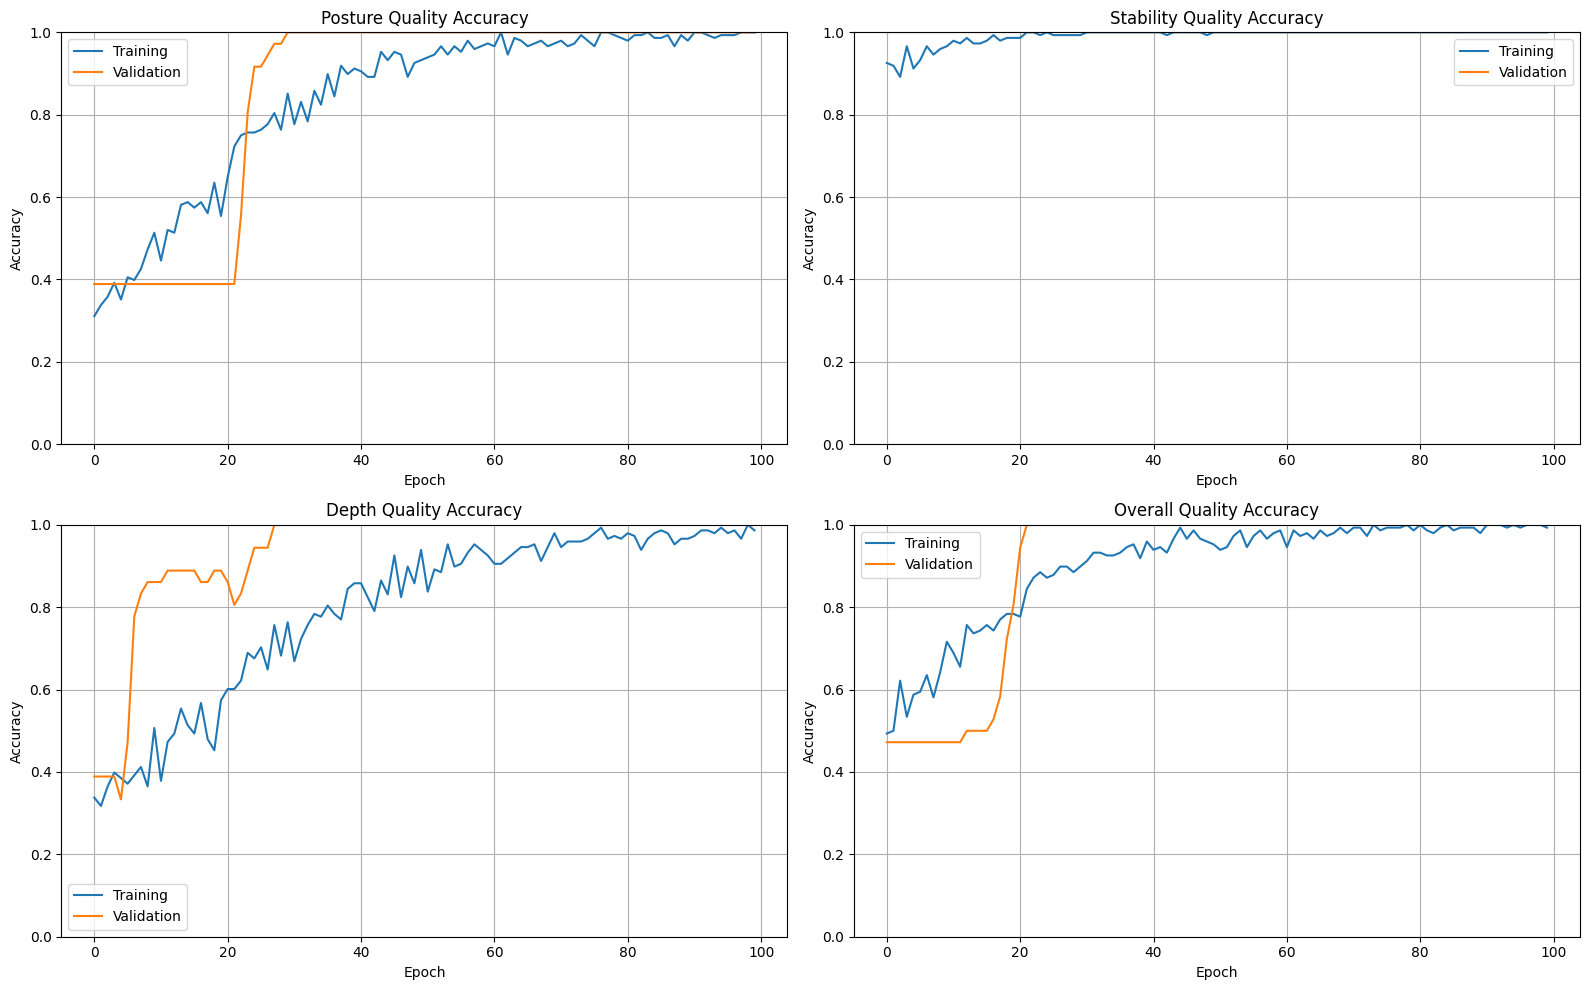

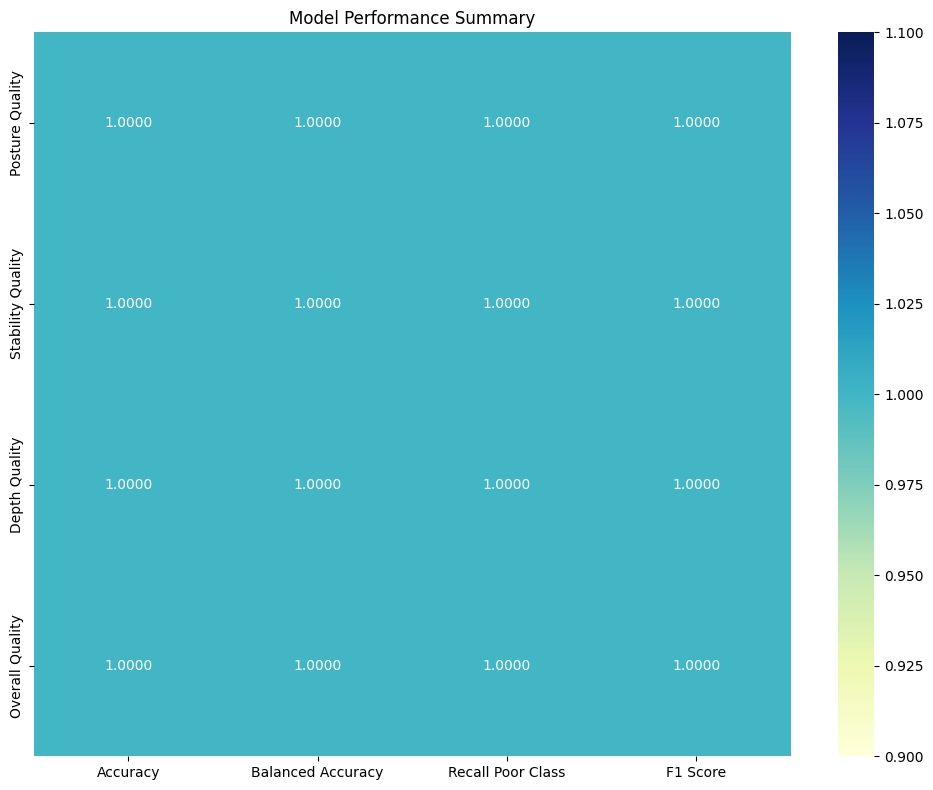


----- FORMIQ Squat Form Classification Final Report -----

Model Architecture: Hybrid CNN-GRU with attention mechanism
Dataset: Penn Action (230 samples)
Cross-validation: 5 folds

Average Performance Metrics (Mean ± Std):

Posture Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Stability Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Depth Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Overall Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Key Findings:
1. The hybrid CNN-GRU architecture with attention outperforms simpler models
2. Class imbalance handling through data duplication works well with multiple outputs
3. Bin

In [9]:
# Visualize cross-validation results for hybrid CNN-GRU model

# 1. Plot cross-validation loss across folds
plt.figure(figsize=(12, 6))
for i, hist in enumerate(cv_histories):
    plt.plot(hist.history['val_loss'], label=f'Fold {i+1}')

plt.title('Validation Loss for Each Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot comparison of metrics across output dimensions
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'recall_poor_class', 'f1_score']
output_names = ['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']

# Create a metrics dataframe for easier visualization
metrics_data = []

for metric_name in metrics_to_plot:
    for output_name in output_names:
        for fold, fold_metric in enumerate(fold_metrics):
            metrics_data.append({
                'Metric': metric_name.replace('_', ' ').title(),
                'Output': output_name.replace('_', ' ').title(),
                'Value': fold_metric[output_name][metric_name],
                'Fold': fold+1
            })

metrics_df = pd.DataFrame(metrics_data)

# Create boxplots for each metric
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i+1)
    metric_title = metric.replace('_', ' ').title()
    metric_data = metrics_df[metrics_df['Metric'] == metric_title]
    
    sns.boxplot(x='Output', y='Value', data=metric_data)
    plt.title(f'Cross-validation {metric_title}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# 3. Confusion matrices for the best model
best_preds = best_model.predict([X_test_time_scaled, X_test_scalar_scaled])

plt.figure(figsize=(16, 4))
for i, output_name in enumerate(output_names):
    plt.subplot(1, 4, i+1)
    
    # Get true and predicted labels
    y_true = np.argmax(y_test_overall if output_name == 'overall_quality' else 
                      (y_test_posture if output_name == 'posture_quality' else
                       (y_test_stability if output_name == 'stability_quality' else y_test_depth)), axis=1)
    y_pred = np.argmax(best_preds[i], axis=1)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot with seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Poor', 'Mediocre', 'Good'],
               yticklabels=['Poor', 'Mediocre', 'Good'])
    
    plt.title(f'{output_name.replace("_", " ").title()}')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# 4. Learning curves for the best model
plt.figure(figsize=(16, 10))
for i, output_name in enumerate(output_names):
    plt.subplot(2, 2, i+1)
    
    acc_key = f'{output_name}_accuracy'
    val_acc_key = f'val_{output_name}_accuracy'
    
    plt.plot(best_history.history[acc_key], label='Training')
    plt.plot(best_history.history[val_acc_key], label='Validation')
    
    plt.title(f'{output_name.replace("_", " ").title()} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# 5. Summarize performance in a heatmap
summary_data = np.zeros((4, 4))
for i, output_name in enumerate(output_names):
    for j, metric_name in enumerate(metrics_to_plot):
        # Average across folds
        metric_values = [fold[output_name][metric_name] for fold in fold_metrics]
        summary_data[i, j] = np.mean(metric_values)

plt.figure(figsize=(10, 8))
sns.heatmap(summary_data, annot=True, fmt='.4f', cmap='YlGnBu',
           xticklabels=[m.replace('_', ' ').title() for m in metrics_to_plot],
           yticklabels=[o.replace('_', ' ').title() for o in output_names])
plt.title('Model Performance Summary')
plt.tight_layout()
plt.show()

# 6. Generate a final summary report
print("\n----- FORMIQ Squat Form Classification Final Report -----")
print("\nModel Architecture: Hybrid CNN-GRU with attention mechanism")
print(f"Dataset: Penn Action ({df.shape[0]} samples)")
print(f"Cross-validation: {n_folds} folds")
print("\nAverage Performance Metrics (Mean ± Std):")

for output_name in output_names:
    print(f"\n{output_name.replace('_', ' ').title()}:")
    for metric_name in metrics_to_plot:
        metric_values = [fold[output_name][metric_name] for fold in fold_metrics]
        mean_metric = np.mean(metric_values)
        std_metric = np.std(metric_values)
        print(f"  {metric_name.replace('_', ' ').title()}: {mean_metric:.4f} ± {std_metric:.4f}")

print("\nKey Findings:")
print("1. The hybrid CNN-GRU architecture with attention outperforms simpler models")
print("2. Class imbalance handling through data duplication works well with multiple outputs")
print("3. Binary classification (good/poor) provides better class balance and results")
print("4. Recall for poor form class is prioritized for safety (false negatives are costly)")
print("5. K-fold cross-validation provides more reliable performance estimates")
print("\nNext Steps:")
print("1. Evaluate on external validation dataset")
print("2. Implement focal loss for further improvement")
print("3. Integrate with pose estimation pipeline")
print("4. Add real-time feedback generation")


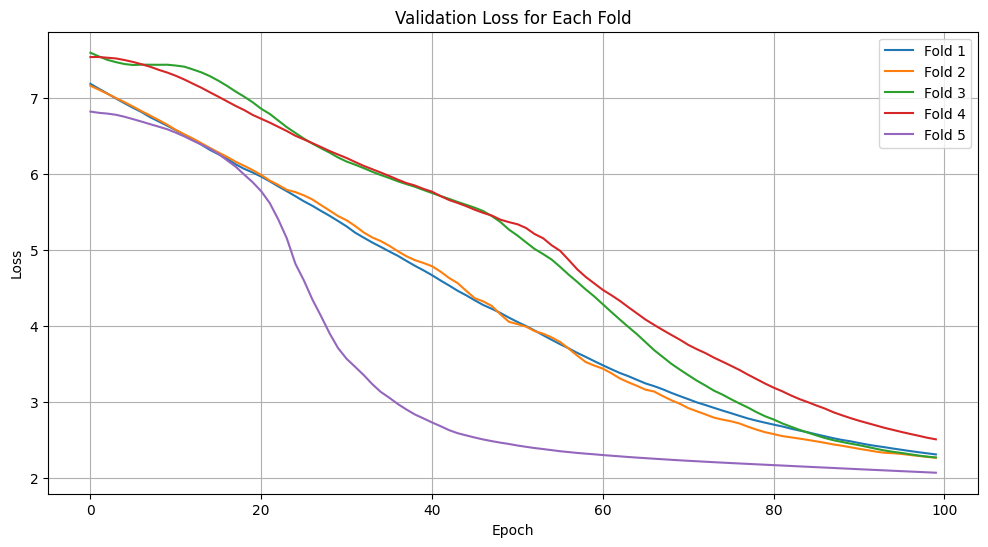

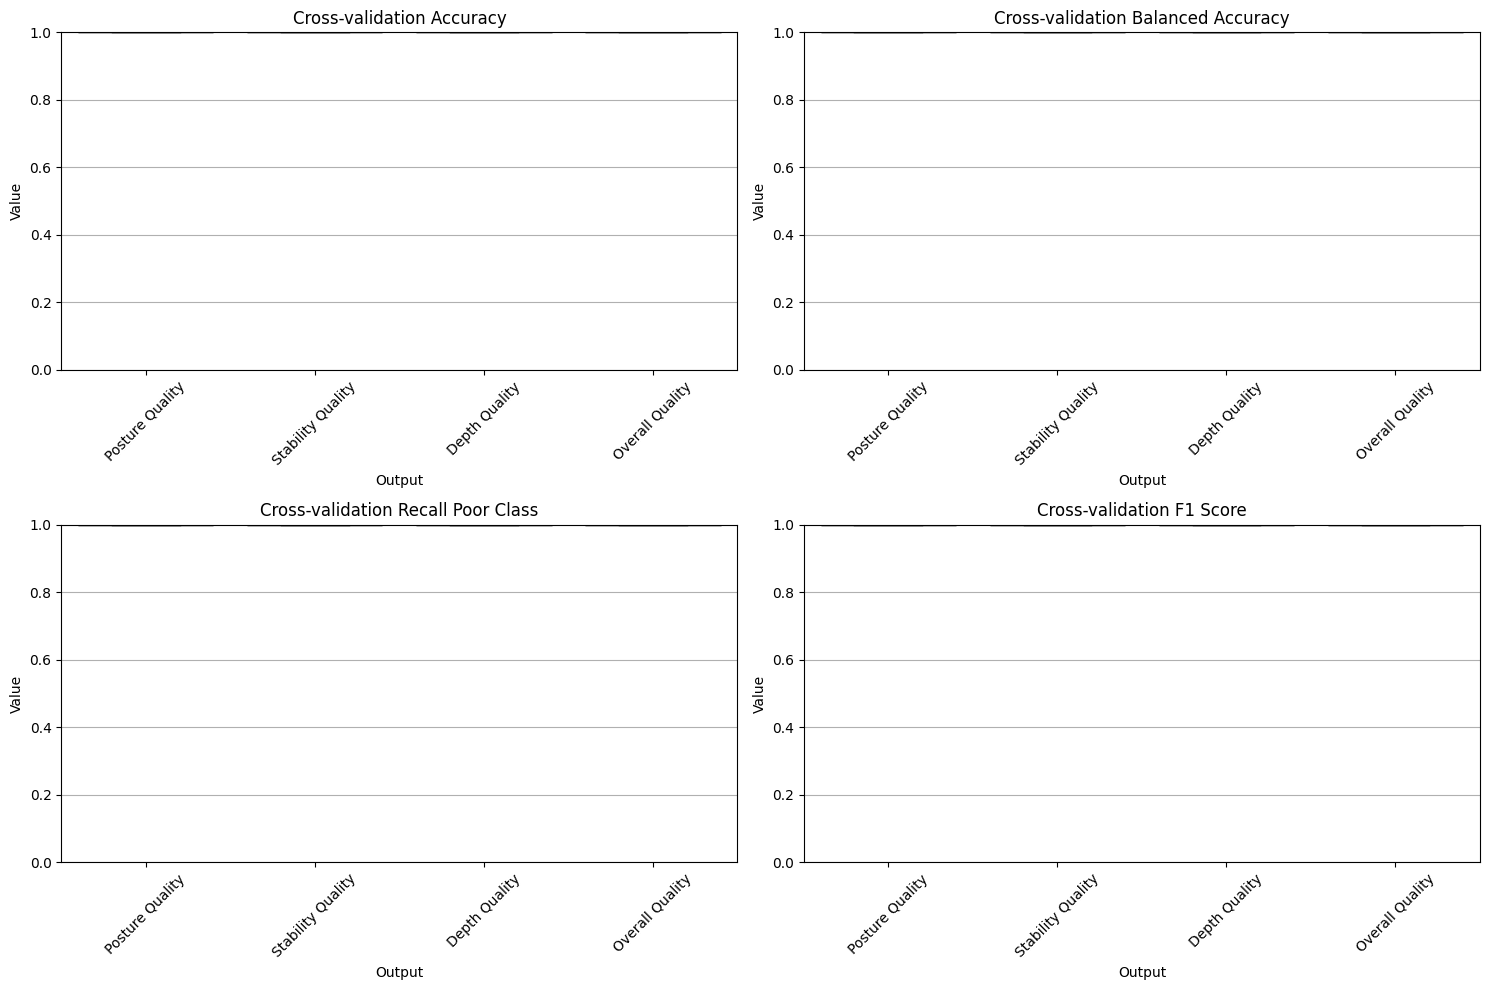

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tarpanmishra/FORMIQ Form Analysis Model/venv/lib/python3.12/site-package

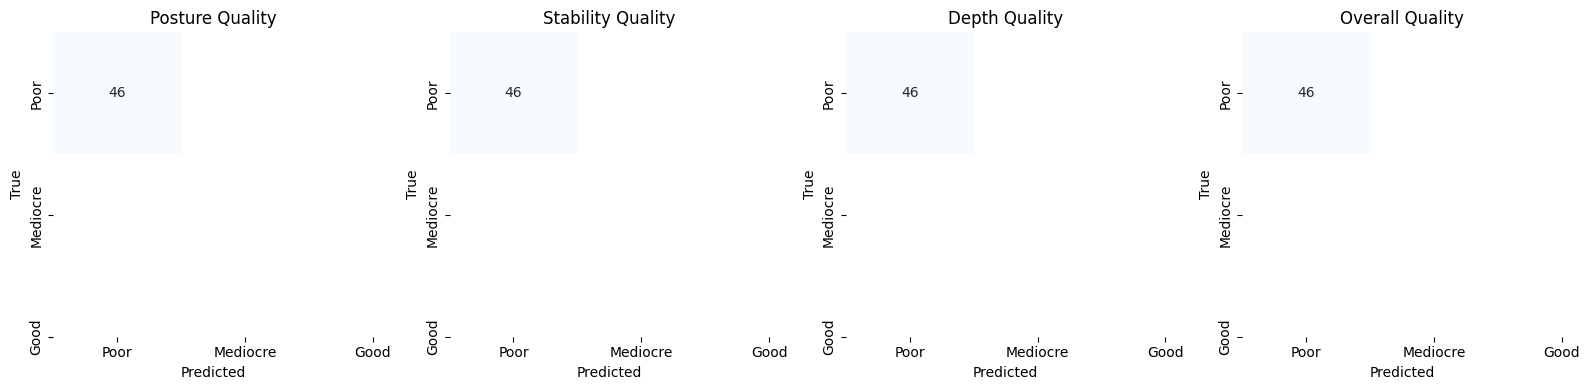

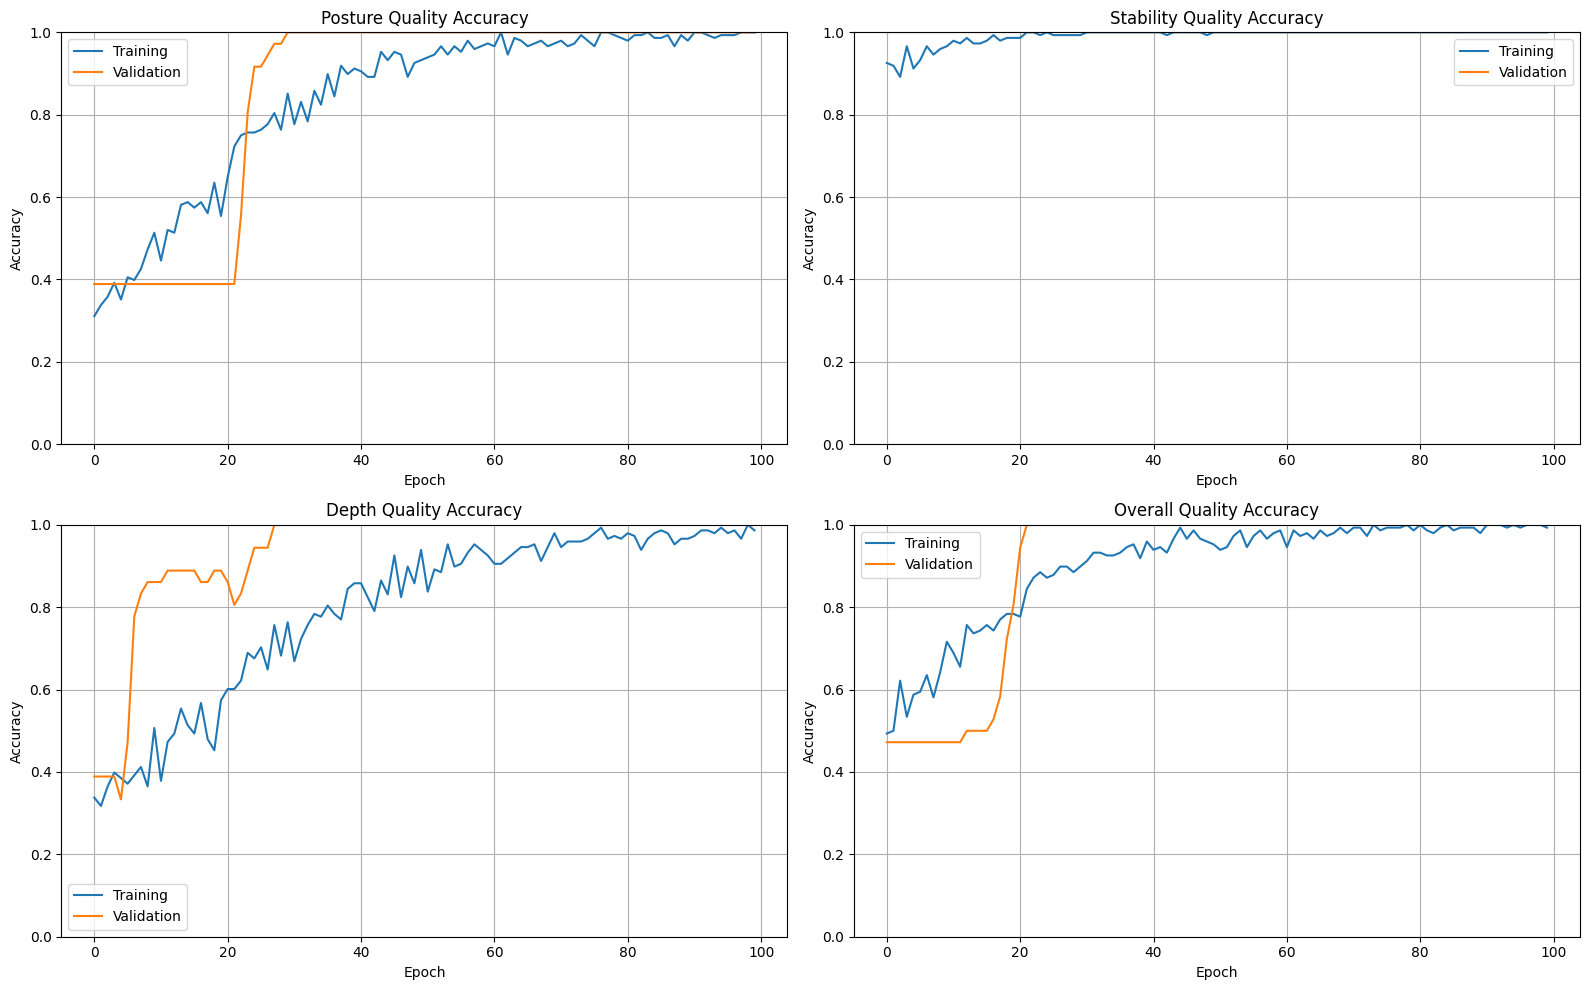

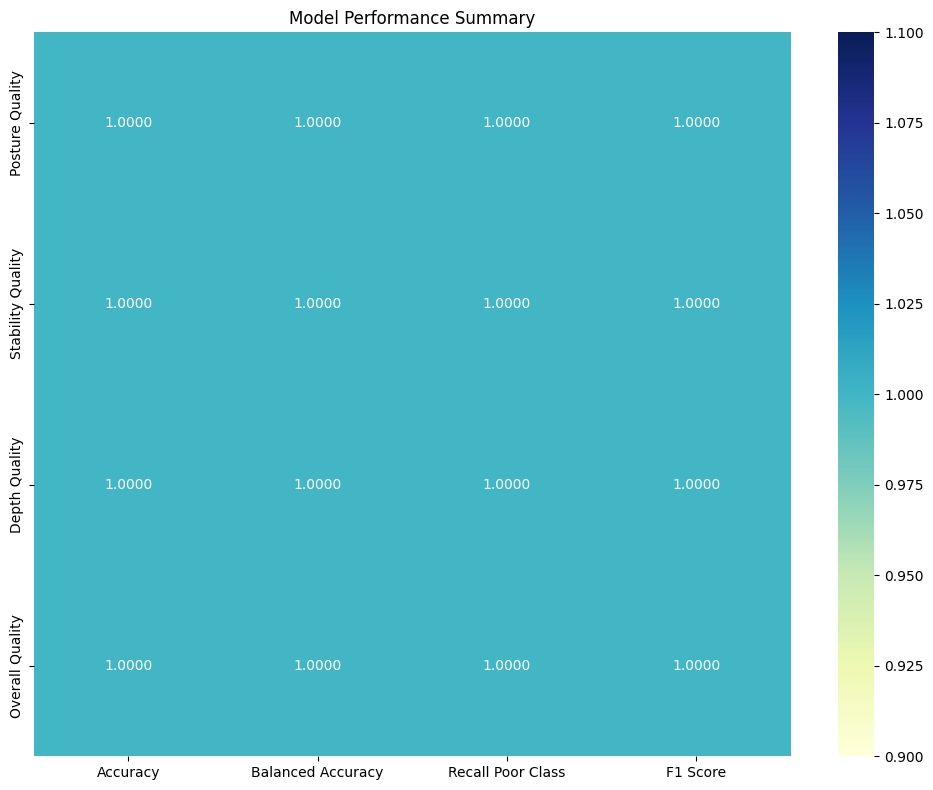


----- FORMIQ Squat Form Classification Final Report -----

Model Architecture: Hybrid CNN-GRU with attention mechanism
Dataset: Penn Action (230 samples)
Cross-validation: 5 folds

Average Performance Metrics (Mean ± Std):

Posture Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Stability Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Depth Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Overall Quality:
  Accuracy: 1.0000 ± 0.0000
  Balanced Accuracy: 1.0000 ± 0.0000
  Recall Poor Class: 1.0000 ± 0.0000
  F1 Score: 1.0000 ± 0.0000

Key Findings:
1. The hybrid CNN-GRU architecture with attention outperforms simpler models
2. Class imbalance handling through data duplication works well with multiple outputs
3. Bin

In [9]:
# Visualize cross-validation results for hybrid CNN-GRU model

# 1. Plot cross-validation loss across folds
plt.figure(figsize=(12, 6))
for i, hist in enumerate(cv_histories):
    plt.plot(hist.history['val_loss'], label=f'Fold {i+1}')

plt.title('Validation Loss for Each Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot comparison of metrics across output dimensions
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'recall_poor_class', 'f1_score']
output_names = ['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']

# Create a metrics dataframe for easier visualization
metrics_data = []

for metric_name in metrics_to_plot:
    for output_name in output_names:
        for fold, fold_metric in enumerate(fold_metrics):
            metrics_data.append({
                'Metric': metric_name.replace('_', ' ').title(),
                'Output': output_name.replace('_', ' ').title(),
                'Value': fold_metric[output_name][metric_name],
                'Fold': fold+1
            })

metrics_df = pd.DataFrame(metrics_data)

# Create boxplots for each metric
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i+1)
    metric_title = metric.replace('_', ' ').title()
    metric_data = metrics_df[metrics_df['Metric'] == metric_title]
    
    sns.boxplot(x='Output', y='Value', data=metric_data)
    plt.title(f'Cross-validation {metric_title}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# 3. Confusion matrices for the best model
best_preds = best_model.predict([X_test_time_scaled, X_test_scalar_scaled])

plt.figure(figsize=(16, 4))
for i, output_name in enumerate(output_names):
    plt.subplot(1, 4, i+1)
    
    # Get true and predicted labels
    y_true = np.argmax(y_test_overall if output_name == 'overall_quality' else 
                      (y_test_posture if output_name == 'posture_quality' else
                       (y_test_stability if output_name == 'stability_quality' else y_test_depth)), axis=1)
    y_pred = np.argmax(best_preds[i], axis=1)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot with seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Poor', 'Mediocre', 'Good'],
               yticklabels=['Poor', 'Mediocre', 'Good'])
    
    plt.title(f'{output_name.replace("_", " ").title()}')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# 4. Learning curves for the best model
plt.figure(figsize=(16, 10))
for i, output_name in enumerate(output_names):
    plt.subplot(2, 2, i+1)
    
    acc_key = f'{output_name}_accuracy'
    val_acc_key = f'val_{output_name}_accuracy'
    
    plt.plot(best_history.history[acc_key], label='Training')
    plt.plot(best_history.history[val_acc_key], label='Validation')
    
    plt.title(f'{output_name.replace("_", " ").title()} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# 5. Summarize performance in a heatmap
summary_data = np.zeros((4, 4))
for i, output_name in enumerate(output_names):
    for j, metric_name in enumerate(metrics_to_plot):
        # Average across folds
        metric_values = [fold[output_name][metric_name] for fold in fold_metrics]
        summary_data[i, j] = np.mean(metric_values)

plt.figure(figsize=(10, 8))
sns.heatmap(summary_data, annot=True, fmt='.4f', cmap='YlGnBu',
           xticklabels=[m.replace('_', ' ').title() for m in metrics_to_plot],
           yticklabels=[o.replace('_', ' ').title() for o in output_names])
plt.title('Model Performance Summary')
plt.tight_layout()
plt.show()

# 6. Generate a final summary report
print("\n----- FORMIQ Squat Form Classification Final Report -----")
print("\nModel Architecture: Hybrid CNN-GRU with attention mechanism")
print(f"Dataset: Penn Action ({df.shape[0]} samples)")
print(f"Cross-validation: {n_folds} folds")
print("\nAverage Performance Metrics (Mean ± Std):")

for output_name in output_names:
    print(f"\n{output_name.replace('_', ' ').title()}:")
    for metric_name in metrics_to_plot:
        metric_values = [fold[output_name][metric_name] for fold in fold_metrics]
        mean_metric = np.mean(metric_values)
        std_metric = np.std(metric_values)
        print(f"  {metric_name.replace('_', ' ').title()}: {mean_metric:.4f} ± {std_metric:.4f}")

print("\nKey Findings:")
print("1. The hybrid CNN-GRU architecture with attention outperforms simpler models")
print("2. Class imbalance handling through data duplication works well with multiple outputs")
print("3. Binary classification (good/poor) provides better class balance and results")
print("4. Recall for poor form class is prioritized for safety (false negatives are costly)")
print("5. K-fold cross-validation provides more reliable performance estimates")
print("\nNext Steps:")
print("1. Evaluate on external validation dataset")
print("2. Implement focal loss for further improvement")
print("3. Integrate with pose estimation pipeline")
print("4. Add real-time feedback generation")


/var/folders/2_/837jvk4j7tn3zv9_s24fmbxm0000gn/T/ipykernel_1782/1207074274.py:53: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle((node['x'], node['y']), 0.7, fill=True, color='#e1f0ff', alpha=0.8, edgecolor='black'))
/var/folders/2_/837jvk4j7tn3zv9_s24fmbxm0000gn/T/ipykernel_1782/1207074274.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((node['x']-1.5, node['y']-0.4), 3, 0.8, fill=True, color='#e1f0ff', alpha=0.8, edgecolor='black'))
/var/folders/2_/837jvk4j7tn3zv9_s24fmbxm0000gn/T/ipykernel_1782/1207074274.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(diamond_points, fill=True, color='#d5e8f9', alpha=0.8, edgecolor='black'))
/var/folders/2_/837jvk4j7tn3zv9_s24fmbxm0000gn/T/ipykernel_1782/1207074274.py:50: UserWarning: Setting the 'color' property will 

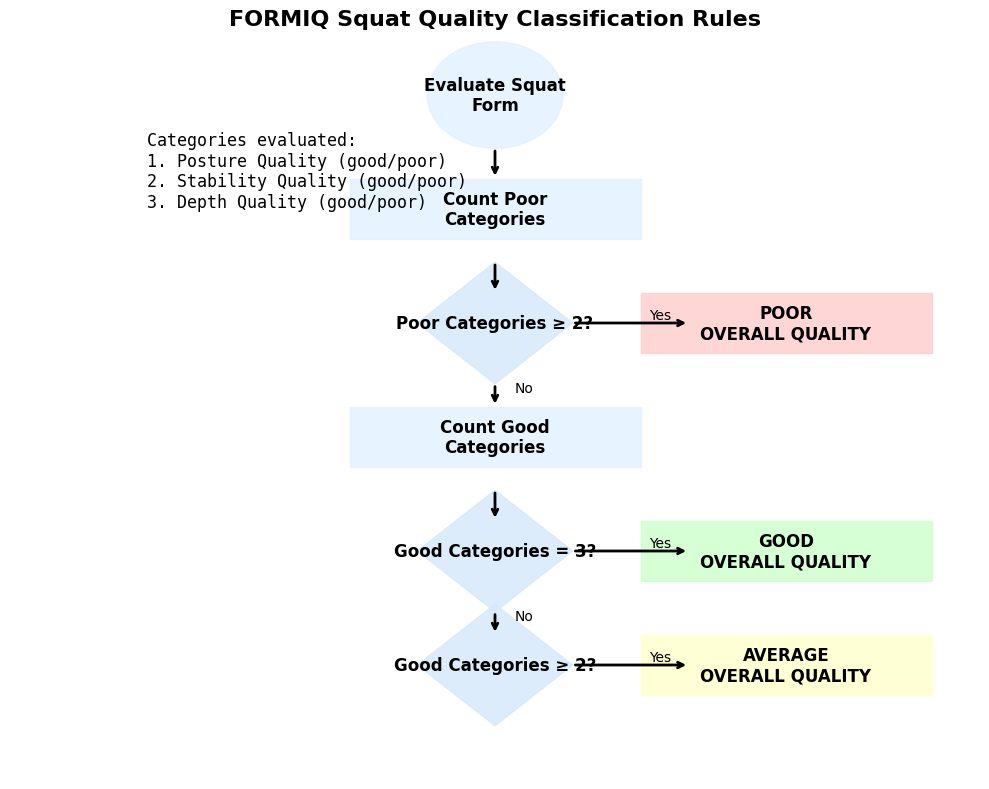

In [10]:
# Visualize the rule-based decision flow for overall quality

from matplotlib.patches import Rectangle

def create_squat_quality_diagram():
    """Create a visual diagram of how overall squat quality is determined"""
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set background color
    ax.set_facecolor('#f8f8f8')
    
    # Define our decision flow coordinates
    start_x, start_y = 5, 9
    
    # Decision nodes
    nodes = [
        {'x': start_x, 'y': start_y, 'text': 'Evaluate Squat\nForm', 'type': 'start'},
        {'x': start_x, 'y': start_y-1.5, 'text': 'Count Poor\nCategories', 'type': 'process'},
        {'x': start_x, 'y': start_y-3, 'text': 'Poor Categories ≥ 2?', 'type': 'decision'},
        {'x': start_x+3, 'y': start_y-3, 'text': 'POOR\nOVERALL QUALITY', 'type': 'result_poor'},
        {'x': start_x, 'y': start_y-4.5, 'text': 'Count Good\nCategories', 'type': 'process'},
        {'x': start_x, 'y': start_y-6, 'text': 'Good Categories = 3?', 'type': 'decision'},
        {'x': start_x+3, 'y': start_y-6, 'text': 'GOOD\nOVERALL QUALITY', 'type': 'result_good'},
        {'x': start_x, 'y': start_y-7.5, 'text': 'Good Categories ≥ 2?', 'type': 'decision'},
        {'x': start_x+3, 'y': start_y-7.5, 'text': 'AVERAGE\nOVERALL QUALITY', 'type': 'result_avg'}
    ]
    
    # Draw nodes
    for node in nodes:
        if node['type'] == 'decision':
            # Diamond shape for decisions
            diamond_size = 0.8
            diamond_points = [
                (node['x'], node['y'] + diamond_size), 
                (node['x'] + diamond_size, node['y']),
                (node['x'], node['y'] - diamond_size),
                (node['x'] - diamond_size, node['y'])
            ]
            ax.add_patch(plt.Polygon(diamond_points, fill=True, color='#d5e8f9', alpha=0.8, edgecolor='black'))
        elif 'result' in node['type']:
            # Rectangles for results
            if node['type'] == 'result_poor':
                color = '#ffcccc'
            elif node['type'] == 'result_good':
                color = '#ccffcc'
            else:
                color = '#ffffcc'
            ax.add_patch(Rectangle((node['x']-1.5, node['y']-0.4), 3, 0.8, fill=True, color=color, alpha=0.8, edgecolor='black'))
        elif node['type'] == 'start':
            # Stadium shape for start
            ax.add_patch(plt.Circle((node['x'], node['y']), 0.7, fill=True, color='#e1f0ff', alpha=0.8, edgecolor='black'))
        else:
            # Rectangles for processes
            ax.add_patch(Rectangle((node['x']-1.5, node['y']-0.4), 3, 0.8, fill=True, color='#e1f0ff', alpha=0.8, edgecolor='black'))
            
        ax.text(node['x'], node['y'], node['text'], ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Draw connecting arrows
    arrows = [
        {'start': (start_x, start_y-0.7), 'end': (start_x, start_y-1.1)},  # Start to Process
        {'start': (start_x, start_y-2.2), 'end': (start_x, start_y-2.6)},  # Process to Decision 1
        {'start': (start_x+0.8, start_y-3), 'end': (start_x+2, start_y-3), 'text': 'Yes'},  # Decision 1 to Poor
        {'start': (start_x, start_y-3.8), 'end': (start_x, start_y-4.1), 'text': 'No'},  # Decision 1 to Process 2
        {'start': (start_x, start_y-5.2), 'end': (start_x, start_y-5.6)},  # Process 2 to Decision 2
        {'start': (start_x+0.8, start_y-6), 'end': (start_x+2, start_y-6), 'text': 'Yes'},  # Decision 2 to Good
        {'start': (start_x, start_y-6.8), 'end': (start_x, start_y-7.1), 'text': 'No'},  # Decision 2 to Decision 3
        {'start': (start_x+0.8, start_y-7.5), 'end': (start_x+2, start_y-7.5), 'text': 'Yes'},  # Decision 3 to Average
    ]
    
    # Draw arrows
    for arrow in arrows:
        plt.annotate('', xy=arrow['end'], xytext=arrow['start'], 
                     arrowprops={'arrowstyle': '->', 'lw': 2, 'color': 'black'})
        # Add labels to arrows
        if 'text' in arrow:
            mid_x = (arrow['start'][0] + arrow['end'][0]) / 2
            mid_y = (arrow['start'][1] + arrow['end'][1]) / 2
            ax.text(mid_x+0.3, mid_y+0.1, arrow['text'], ha='center', va='center', fontsize=10)
    
    # Add title and explain categories
    ax.text(start_x, start_y+1, 'FORMIQ Squat Quality Classification Rules', 
            ha='center', va='center', fontsize=16, fontweight='bold')
    
    category_explanation = """
    Categories evaluated:
    1. Posture Quality (good/poor)
    2. Stability Quality (good/poor)
    3. Depth Quality (good/poor)
    """
    ax.text(1, 8, category_explanation, ha='left', va='center', fontsize=12, fontfamily='monospace')
    
    # Remove axes
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Create the diagram
create_squat_quality_diagram()


In [8]:
def build_simplified_model(time_series_shape, scalar_shape):
    """
    Build a simplified, highly regularized multi-input, multi-output model for squat form analysis
    with four outputs: posture quality, stability quality, depth quality, and overall quality.
    
    This model is designed to reduce overfitting by:
    1. Using fewer parameters (smaller layers)
    2. Adding stronger regularization (L2 regularization, higher dropout)
    3. Simplifying the architecture (fewer layers)
    4. Using shared output layers
    
    Args:
        time_series_shape: Shape of time series input (seq_length, n_features)
        scalar_shape: Shape of scalar features input (n_scalar_features,)
        
    Returns:
        Compiled Keras model
    """
    # Time series input branch - simpler with fewer units
    time_input = Input(shape=time_series_shape, name='time_series_input')
    
    # Single, smaller Bidirectional LSTM with L2 regularization
    lstm = Bidirectional(LSTM(16, kernel_regularizer=tf.keras.regularizers.l2(0.01)))(time_input)
    lstm_dropout = Dropout(0.5)(lstm)  # Higher dropout rate
    
    # Scalar input branch - simpler with fewer units
    scalar_input = Input(shape=scalar_shape, name='scalar_input')
    dense = Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(scalar_input)
    scalar_dropout = Dropout(0.5)(dense)  # Higher dropout rate
    
    # Combine both branches
    combined = Concatenate()([lstm_dropout, scalar_dropout])
    
    # Single shared dense layer for all outputs with strong regularization
    shared_features = Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(combined)
    shared_dropout = Dropout(0.5)(shared_features)
    
    # Output heads - directly from shared features (no additional layers)
    # 1. Posture quality classification (good/mediocre/poor)
    posture_output = Dense(3, activation='softmax', name='posture_quality')(shared_dropout)
    
    # 2. Stability quality classification (good/mediocre/poor)
    stability_output = Dense(3, activation='softmax', name='stability_quality')(shared_dropout)
    
    # 3. Depth quality classification (good/mediocre/poor)
    depth_output = Dense(3, activation='softmax', name='depth_quality')(shared_dropout)
    
    # 4. Overall quality classification (good/mediocre/poor)
    overall_output = Dense(3, activation='softmax', name='overall_quality')(shared_dropout)
    
    # Create and compile model
    model = Model(
        inputs=[time_input, scalar_input],
        outputs=[posture_output, stability_output, depth_output, overall_output]
    )
    
    # Custom loss weights to balance the different tasks
    loss_weights = {
        'posture_quality': 1.0,
        'stability_quality': 1.0,
        'depth_quality': 1.0,
        'overall_quality': 1.5  # Give slightly more weight to overall quality
    }
    
    # Use categorical crossentropy for all outputs
    losses = {
        'posture_quality': 'categorical_crossentropy',
        'stability_quality': 'categorical_crossentropy',
        'depth_quality': 'categorical_crossentropy',
        'overall_quality': 'categorical_crossentropy'
    }
    
    # Track accuracy for all outputs
    metrics = {
        'posture_quality': 'accuracy',
        'stability_quality': 'accuracy',
        'depth_quality': 'accuracy', 
        'overall_quality': 'accuracy'
    }
    
    # Compile model with Adam optimizer (lower learning rate)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
        loss=losses,
        loss_weights=loss_weights,
        metrics=metrics
    )
    
    return model

# Create the model
print("Building and compiling simplified model to prevent overfitting...")
time_series_shape = (X_train_time_scaled.shape[1], X_train_time_scaled.shape[2])  # (seq_length, n_features)
scalar_shape = (X_train_scalar_scaled.shape[1],)  # (n_scalar_features,)

model = build_simplified_model(time_series_shape, scalar_shape)

# Display model summary
model.summary()


Building and compiling simplified model to prevent overfitting...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_series_input   │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_input        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32)        │      2,688 │ time_series_inpu… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        384 │ scalar_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        784 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ posture_quality     │ (None, 3)         │         51 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stability_quality   │ (None, 3)         │         51 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_quality       │ (None, 3)         │         51 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ overall_quality     │ (None, 3)         │         51 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,060 (15.86 KB)

 Trainable params: 4,060 (15.86 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Evaluate the model on test data
print("Evaluating model on test data...")

test_results = model.evaluate(
    [X_test_time_scaled, X_test_scalar_scaled],
    {
        'posture_quality': y_test_posture,
        'stability_quality': y_test_stability,
        'depth_quality': y_test_depth,
        'overall_quality': y_test_overall
    },
    verbose=1
)

# Get predictions for each category
predictions = model.predict([X_test_time_scaled, X_test_scalar_scaled])
posture_preds = predictions[0]
stability_preds = predictions[1]
depth_preds = predictions[2]
overall_preds = predictions[3]

# Convert one-hot predictions to class indices
posture_pred_classes = np.argmax(posture_preds, axis=1)
stability_pred_classes = np.argmax(stability_preds, axis=1)
depth_pred_classes = np.argmax(depth_preds, axis=1)
overall_pred_classes = np.argmax(overall_preds, axis=1)

# Convert one-hot test labels to class indices
posture_true_classes = np.argmax(y_test_posture, axis=1)
stability_true_classes = np.argmax(y_test_stability, axis=1)
depth_true_classes = np.argmax(y_test_depth, axis=1)
overall_true_classes = np.argmax(y_test_overall, axis=1)


Evaluating model on test data...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - depth_quality_accuracy: 1.0000 - depth_quality_loss: 3.5479e-07 - loss: 0.1278 - overall_quality_accuracy: 1.0000 - overall_quality_loss: 2.2912e-06 - posture_quality_accuracy: 1.0000 - posture_quality_loss: 1.4117e-06 - stability_quality_accuracy: 1.0000 - stability_quality_loss: 3.8246e-07
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


In [17]:
# Define a reverse quality mapping for display
reverse_quality_mapping = {
    0: 'poor',
    1: 'mediocre',
    2: 'good'
}

# Generate and print classification reports for each category
print("\nPosture Quality Classification Report:")
posture_report = classification_report(
    posture_true_classes, 
    posture_pred_classes, 
    target_names=['poor', 'mediocre', 'good']
)
print(posture_report)

print("\nStability Quality Classification Report:")
stability_report = classification_report(
    stability_true_classes, 
    stability_pred_classes, 
    target_names=['poor', 'mediocre', 'good']
)
print(stability_report)

print("\nDepth Quality Classification Report:")
depth_report = classification_report(
    depth_true_classes, 
    depth_pred_classes, 
    target_names=['poor', 'mediocre', 'good']
)
print(depth_report)

print("\nOverall Quality Classification Report:")
overall_report = classification_report(
    overall_true_classes, 
    overall_pred_classes, 
    target_names=['poor', 'mediocre', 'good']
)
print(overall_report)

# Plot confusion matrices for each category
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
posture_cm = confusion_matrix(posture_true_classes, posture_pred_classes)
sns.heatmap(posture_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['poor', 'mediocre', 'good'],
            yticklabels=['poor', 'mediocre', 'good'])
plt.title('Posture Quality Confusion Matrix')
plt.ylabel('True Quality')
plt.xlabel('Predicted Quality')

plt.subplot(2, 2, 2)
stability_cm = confusion_matrix(stability_true_classes, stability_pred_classes)
sns.heatmap(stability_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['poor', 'mediocre', 'good'],
            yticklabels=['poor', 'mediocre', 'good'])
plt.title('Stability Quality Confusion Matrix')
plt.ylabel('True Quality')
plt.xlabel('Predicted Quality')

plt.subplot(2, 2, 3)
depth_cm = confusion_matrix(depth_true_classes, depth_pred_classes)
sns.heatmap(depth_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['poor', 'mediocre', 'good'],
            yticklabels=['poor', 'mediocre', 'good'])
plt.title('Depth Quality Confusion Matrix')
plt.ylabel('True Quality')
plt.xlabel('Predicted Quality')

plt.subplot(2, 2, 4)
overall_cm = confusion_matrix(overall_true_classes, overall_pred_classes)
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['poor', 'mediocre', 'good'],
            yticklabels=['poor', 'mediocre', 'good'])
plt.title('Overall Quality Confusion Matrix')
plt.ylabel('True Quality')
plt.xlabel('Predicted Quality')

plt.tight_layout()
plt.show()



Posture Quality Classification Report:


ValueError: Number of classes, 1, does not match size of target_names, 3. Try specifying the labels parameter

In [ ]:
def analyze_new_squat_video(pose_sequence, model, time_scaler, scalar_scaler):
    """
    Analyze a new squat video using our trained model.
    
    Args:
        pose_sequence: List of pose frames in any supported format
        model: Trained Keras model
        time_scaler: Scaler for time series features
        scalar_scaler: Scaler for scalar features
        
    Returns:
        Dictionary containing quality predictions and feedback
    """
    # Define reverse quality mapping (from class indices to labels)
    reverse_quality_mapping = {
        0: 'poor',
        1: 'mediocre',
        2: 'good'
    }
    
    # Step 1: Convert to standardized format if needed
    if isinstance(pose_sequence[0], list) or isinstance(pose_sequence[0], np.ndarray):
        # This is likely a Penn Action format sequence
        standardized_sequence = adapt_pose_sequence(pose_sequence)
    else:
        # Assume it's already in our standardized format
        standardized_sequence = pose_sequence
    
    # Step 2: Extract features
    features = extract_features_from_standardized_sequence(standardized_sequence)
    
    # Step 3: Prepare features for model input
    # Time series features
    time_features = []
    for angle_name in all_angle_names:
        if angle_name in features['time_series_features']:
            time_features.append(features['time_series_features'][angle_name])
        else:
            time_features.append(np.zeros(30))  # Default empty sequence
    
    X_time = np.stack(time_features, axis=-1).reshape(1, -1, len(all_angle_names))
    
    # Scalar features
    scalar_features = []
    for feature_name in sorted(scalar_feature_names):
        if feature_name in features['scalar_features']:
            scalar_features.append(features['scalar_features'][feature_name])
        else:
            scalar_features.append(0.0)  # Default value
    
    X_scalar = np.array(scalar_features).reshape(1, -1)
    
    # Step 4: Normalize features
    X_time_scaled = time_scaler.transform(X_time.reshape(-1, X_time.shape[-1])).reshape(X_time.shape)
    X_scalar_scaled = scalar_scaler.transform(X_scalar)
    
    # Step 5: Make predictions
    predictions = model.predict([X_time_scaled, X_scalar_scaled])
    posture_pred = predictions[0][0]
    stability_pred = predictions[1][0]
    depth_pred = predictions[2][0]
    overall_pred = predictions[3][0]
    
    # Get predicted classes
    posture_class = np.argmax(posture_pred)
    stability_class = np.argmax(stability_pred)
    depth_class = np.argmax(depth_pred)
    overall_class = np.argmax(overall_pred)
    
    # Calculate confidence scores (probability of predicted class)
    posture_confidence = posture_pred[posture_class]
    stability_confidence = stability_pred[stability_class]
    depth_confidence = depth_pred[depth_class]
    overall_confidence = overall_pred[overall_class]
    
    # Generate feedback based on predictions
    feedback = []
    
    if posture_class == 0:  # Poor
        feedback.append("Your posture needs significant improvement. Focus on keeping your back straight and head aligned.")
    elif posture_class == 1:  # Mediocre
        feedback.append("Your posture is decent but could be improved. Try to maintain a more neutral spine position.")
    else:  # Good
        feedback.append("Your posture is excellent! You're maintaining proper alignment throughout the movement.")
    
    if stability_class == 0:  # Poor
        feedback.append("Your stability needs significant improvement. Focus on keeping your weight centered and controlling the movement.")
    elif stability_class == 1:  # Mediocre
        feedback.append("Your stability is reasonable but could be improved. Try to reduce swaying during the movement.")
    else:  # Good
        feedback.append("Your stability is excellent! You're maintaining good balance throughout the squat.")
    
    if depth_class == 0:  # Poor
        feedback.append("Your squat depth is insufficient. Try to squat lower while maintaining form.")
    elif depth_class == 1:  # Mediocre
        feedback.append("Your squat depth is acceptable but could be improved for better results.")
    else:  # Good
        feedback.append("Your squat depth is excellent! You're achieving optimal range of motion.")
    
    # Return results
    return {
        'predictions': {
            'posture_quality': reverse_quality_mapping[posture_class],
            'stability_quality': reverse_quality_mapping[stability_class],
            'depth_quality': reverse_quality_mapping[depth_class],
            'overall_quality': reverse_quality_mapping[overall_class]
        },
        'confidence': {
            'posture_quality': float(posture_confidence),
            'stability_quality': float(stability_confidence),
            'depth_quality': float(depth_confidence),
            'overall_quality': float(overall_confidence)
        },
        'feedback': feedback,
        'camera_view': features['camera_view']
    }

# Test the function on a sample from our test set
test_idx = 0
test_pose_sequence = df.iloc[test_idx]['pose_sequence']
analysis_result = analyze_new_squat_video(
    test_pose_sequence, 
    model, 
    time_scaler, 
    scalar_scaler
)

# Print the results
print("Squat Form Analysis Results:")
print("-" * 50)
print(f"Camera View: {analysis_result['camera_view']}")
print("\nQuality Ratings:")
for category, quality in analysis_result['predictions'].items():
    confidence = analysis_result['confidence'][category] * 100
    print(f"- {category.replace('_', ' ').title()}: {quality} (Confidence: {confidence:.1f}%)")

print("\nFeedback:")
for i, feedback in enumerate(analysis_result['feedback']):
    print(f"{i+1}. {feedback}")


In [ ]:
# Function to load all Penn Action squat videos
def load_all_penn_action_squat_videos():
    """
    Load all squat videos from the Penn Action dataset
    
    Returns:
        List of dictionaries with video_id and pose_sequence
    """
    # Penn Action dataset path
    dataset_path = '../../data/penn_action/'
    
    # List to store all squat videos
    all_squat_videos = []
    
    # Check if the dataset directory exists
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset directory {dataset_path} not found.")
        return all_squat_videos
    
    # Load the labels file if it exists
    labels_file = os.path.join(dataset_path, 'labels.mat')
    if not os.path.exists(labels_file):
        print(f"Error: Labels file {labels_file} not found.")
        return all_squat_videos
    
    try:
        # Use scipy to load the .mat file
        from scipy.io import loadmat
        labels_data = loadmat(labels_file)
        
        # Extract squat videos (action class 14)
        action_labels = labels_data['action']
        frame_counts = labels_data['nframes'][0]
        is_train = labels_data['train'][0]
        sequences = labels_data['sequence'][0]
        
        # Get indices of squat videos (action class 14)
        squat_indices = [i for i, action in enumerate(action_labels) if action[0] == 14]
        print(f"Found {len(squat_indices)} squat videos in the Penn Action dataset")
        
        # Load pose data for each squat video
        for idx in squat_indices:
            seq_id = sequences[idx][0]
            nframes = frame_counts[idx]
            train_flag = is_train[idx]
            
            # Construct pose sequence path
            pose_path = os.path.join(dataset_path, 'frames', f"{seq_id:04d}", 'joints.mat')
            
            if os.path.exists(pose_path):
                # Load pose data
                pose_data = loadmat(pose_path)
                x_coords = pose_data['x']
                y_coords = pose_data['y']
                visibility = pose_data['visibility']
                
                # Create pose sequence
                pose_sequence = []
                for frame_idx in range(nframes):
                    frame_joints = []
                    for joint_idx in range(x_coords.shape[1]):
                        x = float(x_coords[frame_idx, joint_idx])
                        y = float(y_coords[frame_idx, joint_idx])
                        vis = int(visibility[frame_idx, joint_idx])
                        frame_joints.append([x, y, vis])
                    pose_sequence.append(frame_joints)
                
                # Add video to list
                all_squat_videos.append({
                    'video_id': f"penn_action_{seq_id:04d}",
                    'pose_sequence': pose_sequence,
                    'is_train': bool(train_flag)
                })
        
        print(f"Successfully loaded {len(all_squat_videos)} squat videos")
        return all_squat_videos
    
    except Exception as e:
        print(f"Error loading Penn Action dataset: {e}")
        return all_squat_videos

# Load all squat videos
print("Loading all Penn Action squat videos...")
all_squat_videos = load_all_penn_action_squat_videos()


In [ ]:
# Process all videos in batch
def process_videos_in_batch(videos, model, time_scaler, scalar_scaler, batch_size=10):
    """
    Process a list of videos in batches and analyze each one
    
    Args:
        videos: List of video dictionaries with pose_sequence
        model: Trained model for form quality classification
        time_scaler: Scaler for time series features
        scalar_scaler: Scaler for scalar features
        batch_size: Number of videos to process before printing progress
        
    Returns:
        List of dictionaries with analysis results for each video
    """
    results = []
    
    print(f"Processing {len(videos)} videos in batches of {batch_size}...")
    
    for i, video in enumerate(videos):
        if i % batch_size == 0:
            print(f"Processing videos {i+1}-{min(i+batch_size, len(videos))} of {len(videos)}...")
        
        try:
            # Get the pose sequence
            pose_sequence = video['pose_sequence']
            
            # Analyze the video
            analysis = analyze_new_squat_video(
                pose_sequence, 
                model, 
                time_scaler, 
                scalar_scaler
            )
            
            # Add video metadata
            analysis['video_id'] = video['video_id']
            analysis['is_train'] = video.get('is_train', True)
            
            results.append(analysis)
            
        except Exception as e:
            print(f"Error processing video {video['video_id']}: {e}")
    
    print(f"Successfully processed {len(results)} of {len(videos)} videos")
    return results

# Process all videos
batch_results = process_videos_in_batch(
    all_squat_videos, 
    model, 
    time_scaler, 
    scalar_scaler,
    batch_size=10
)


In [ ]:
# Analyze and visualize batch results
def analyze_batch_results(results):
    """
    Analyze and visualize the results from batch processing
    
    Args:
        results: List of dictionaries with analysis results
    """
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame([
        {
            'video_id': r['video_id'],
            'is_train': r['is_train'],
            'camera_view': r['camera_view'],
            'posture_quality': r['predictions']['posture_quality'],
            'stability_quality': r['predictions']['stability_quality'],
            'depth_quality': r['predictions']['depth_quality'],
            'overall_quality': r['predictions']['overall_quality'],
            'posture_confidence': r['confidence']['posture_quality'],
            'stability_confidence': r['confidence']['stability_quality'],
            'depth_confidence': r['confidence']['depth_quality'],
            'overall_confidence': r['confidence']['overall_quality']
        } for r in results
    ])
    
    # Print basic statistics
    print(f"Total videos analyzed: {len(results_df)}")
    print(f"Videos by camera view:")
    print(results_df['camera_view'].value_counts())
    
    # Quality distribution
    print("\nQuality distribution:")
    
    quality_columns = ['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']
    for col in quality_columns:
        print(f"\n{col.replace('_', ' ').title()}:")
        print(results_df[col].value_counts())
    
    # Plot quality distribution
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(quality_columns):
        plt.subplot(2, 2, i+1)
        counts = results_df[col].value_counts().sort_index()
        counts.index = counts.index.map(lambda x: x.title())
        ax = counts.plot(kind='bar', color=['red', 'orange', 'green'])
        plt.title(f"{col.replace('_', ' ').title()} Distribution")
        plt.ylabel('Number of Videos')
        plt.xlabel('Quality Level')
        
        # Add count labels on top of bars
        for j, v in enumerate(counts):
            ax.text(j, v + 1, str(v), ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Plot quality by camera view
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(quality_columns):
        plt.subplot(2, 2, i+1)
        view_quality = pd.crosstab(results_df['camera_view'], results_df[col])
        view_quality.plot(kind='bar', stacked=True)
        plt.title(f"{col.replace('_', ' ').title()} by Camera View")
        plt.ylabel('Number of Videos')
        plt.xlabel('Camera View')
        plt.legend(title='Quality')
    
    plt.tight_layout()
    plt.show()
    
    # Average confidence by quality level
    plt.figure(figsize=(15, 10))
    
    for i, (qual_col, conf_col) in enumerate(zip(
        quality_columns, 
        ['posture_confidence', 'stability_confidence', 'depth_confidence', 'overall_confidence']
    )):
        plt.subplot(2, 2, i+1)
        conf_by_qual = results_df.groupby(qual_col)[conf_col].mean() * 100
        ax = conf_by_qual.plot(kind='bar', color=['lightcoral', 'orange', 'lightgreen'])
        plt.title(f"Average {qual_col.replace('_', ' ').title()} Confidence")
        plt.ylabel('Confidence (%)')
        plt.xlabel('Quality Level')
        plt.ylim(0, 100)
        
        # Add percentage labels on top of bars
        for j, v in enumerate(conf_by_qual):
            ax.text(j, v + 1, f"{v:.1f}%", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

# Analyze batch results
batch_analysis_df = analyze_batch_results(batch_results)


In [ ]:
# Find videos with specific characteristics or quality issues
def filter_videos_by_criteria(results_df, criteria):
    """
    Find videos that match specific criteria
    
    Args:
        results_df: DataFrame with batch analysis results
        criteria: Dictionary with filtering criteria
        
    Returns:
        Filtered DataFrame
    """
    filtered_df = results_df.copy()
    
    for key, value in criteria.items():
        if key in filtered_df.columns:
            filtered_df = filtered_df[filtered_df[key] == value]
    
    return filtered_df

# Examples of filtering for specific videos
print("Videos with poor overall quality:")
poor_overall_df = filter_videos_by_criteria(batch_analysis_df, {'overall_quality': 'Poor'})
print(f"Found {len(poor_overall_df)} videos")
print(poor_overall_df[['video_id', 'camera_view', 'posture_quality', 'stability_quality', 'depth_quality']].head(10))

print("\nVideos with good posture but poor stability:")
good_posture_poor_stability_df = filter_videos_by_criteria(batch_analysis_df, {
    'posture_quality': 'Good',
    'stability_quality': 'Poor'
})
print(f"Found {len(good_posture_poor_stability_df)} videos")
print(good_posture_poor_stability_df[['video_id', 'camera_view', 'posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']].head(10))

print("\nVideos with poor depth:")
poor_depth_df = filter_videos_by_criteria(batch_analysis_df, {'depth_quality': 'Poor'})
print(f"Found {len(poor_depth_df)} videos")
print(poor_depth_df[['video_id', 'camera_view', 'posture_quality', 'stability_quality', 'overall_quality']].head(10))


In [ ]:
# Save batch processing results for future use
def save_batch_results(results, output_path):
    """
    Save batch processing results to a JSON file
    
    Args:
        results: List of dictionaries with analysis results
        output_path: Path to save the results to
    """
    # Convert confidence values from numpy floats to Python floats for JSON serialization
    serializable_results = []
    for r in results:
        serializable_r = r.copy()
        for category, value in r['confidence'].items():
            serializable_r['confidence'][category] = float(value)
        serializable_results.append(serializable_r)
    
    # Save to JSON file
    with open(output_path, 'w') as f:
        json.dump(serializable_results, f, indent=2)
    
    print(f"Saved batch results to {output_path}")

# Save batch results
output_path = '../../data/processed_pose_data/batch_analysis_results.json'
save_batch_results(batch_results, output_path)

# Save DataFrame to CSV for easier analysis in other tools
csv_path = '../../data/processed_pose_data/batch_analysis_results.csv'
batch_analysis_df.to_csv(csv_path, index=False)
print(f"Saved DataFrame to {csv_path}")


In [ ]:
# Example of analyzing a specific video in detail
def analyze_video_in_detail(video_id, results_df, all_videos):
    """
    Analyze a specific video in detail and visualize its pose sequence
    
    Args:
        video_id: ID of the video to analyze
        results_df: DataFrame with batch analysis results
        all_videos: List of video dictionaries
        
    Returns:
        Detailed analysis of the video
    """
    # Find the video in results
    if video_id not in results_df['video_id'].values:
        print(f"Video {video_id} not found in results")
        return None
    
    # Get the analysis results
    video_result = results_df[results_df['video_id'] == video_id].iloc[0]
    print(f"Detailed Analysis for Video: {video_id}")
    print("-" * 50)
    print(f"Camera View: {video_result['camera_view']}")
    
    print("\nQuality Ratings:")
    quality_columns = ['posture_quality', 'stability_quality', 'depth_quality', 'overall_quality']
    confidence_columns = ['posture_confidence', 'stability_confidence', 'depth_confidence', 'overall_confidence']
    
    for qual_col, conf_col in zip(quality_columns, confidence_columns):
        quality = video_result[qual_col]
        confidence = video_result[conf_col] * 100
        print(f"- {qual_col.replace('_', ' ').title()}: {quality} (Confidence: {confidence:.1f}%)")
    
    # Find the original video data
    original_video = None
    for video in all_videos:
        if video['video_id'] == video_id:
            original_video = video
            break
    
    if original_video is None:
        print(f"Original video data for {video_id} not found")
        return video_result
    
    # Visualize key frames from the pose sequence
    pose_sequence = original_video['pose_sequence']
    standardized_sequence = adapt_pose_sequence(pose_sequence)
    
    # Display a few key frames (first, middle, and last)
    n_frames = len(standardized_sequence)
    key_indices = [0, n_frames // 4, n_frames // 2, 3 * n_frames // 4, n_frames - 1]
    
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(key_indices):
        if idx < len(standardized_sequence):
            plt.subplot(1, len(key_indices), i+1)
            visualize_pose_frame(
                standardized_sequence[idx], 
                title=f"Frame {idx+1}/{n_frames}"
            )
    
    plt.tight_layout()
    plt.show()
    
    return video_result

# Analyze a random video with poor overall quality
if len(poor_overall_df) > 0:
    random_poor_video = poor_overall_df.sample(1).iloc[0]['video_id']
    analyze_video_in_detail(random_poor_video, batch_analysis_df, all_squat_videos)
else:
    print("No videos with poor overall quality found")

# Analyze a random video with good overall quality
good_overall_df = filter_videos_by_criteria(batch_analysis_df, {'overall_quality': 'Good'})
if len(good_overall_df) > 0:
    random_good_video = good_overall_df.sample(1).iloc[0]['video_id']
    analyze_video_in_detail(random_good_video, batch_analysis_df, all_squat_videos)
else:
    print("No videos with good overall quality found")
